# MANU policy - Prediction and Explanation

Hiểu được khách hàng là chìa khóa thành công cho mọi doanh nghiệp bán hàng.

Bài toán : Dự đoán khách hàng có mua bảo hiểm hay không? Và giải thích được tại sao khách hàng lại mua hàng?

Yêu cầu là dự đoán nhưng thực tế đây là bài toán ranking, vì yêu cầu chúng ta lọc ra 800 người đúng dầu có tỉ lệ mua cao nhất. Vì vậy model phải cho biết được xác suất của các dự đoán để có thể lọc được.

Ta sẽ xây dựng một mô hình học máy để phân tích và học tập từ dữ trong tập train, sau đó áp dụng mô hình với tập test.

- Phương pháp đánh giá dựa trên precision@800 /lift, kèm AUC để so sánh các model.
- Đây là một bố dữ liệu bị mất cân bằng nên cần có các phương pháp để xử lý.

## Tổng quan công việc & kết quả chính

*(Phần này tóm tắt toàn bộ quy trình & phát hiện — tiện cho việc viết báo cáo. Chi tiết ở các mục bên dưới.)*

### 1. Bài toán
- **Task 1 — Dự đoán:** lọc **800/4000** khách test có khả năng mua MANU cao nhất → thực chất là bài **ranking** (cần xác suất để xếp hạng), không phải phân loại 0/1.
- **Task 2 — Giải thích:** vẽ chân dung khách hàng mua MANU (comprehensibility / usefulness / actionability).
- **Đánh giá:** precision@800 / lift (KHÔNG dùng accuracy vì mất cân bằng).

### 2. Dữ liệu & đặc điểm then chốt
- Train **5.822** dòng, test **4.000** dòng; **85 đặc trưng** + ID + target (cột 86). Base rate mua = **5.98%** (mất cân bằng nặng).
- **Socio (cột 1–42) là dữ liệu cấp ZIP-CODE**, không phải cá nhân → 651 dòng trùng đặc trưng; **trần sai số ~2%** (nhãn mâu thuẫn).
- **Sản phẩm bảo hiểm (44–85) là dữ liệu CÁ NHÂN** → đây mới là nguồn tín hiệu phân biệt mạnh nhất.
- 85 cột chia 3 dạng: **36 cột % compositional** (6–41, cộng ≈ 9) · **7 cột đứng riêng** · **42 cột sản phẩm** (21 cặp Contribution↔Number, corr ~0.9).

### 3. Quy trình đã thực hiện
| Bước | Nội dung | Kết quả chính |
|---|---|---|
| Data quality | missing / kiểu / miền / trùng lặp / nhãn mâu thuẫn | Data sạch, 0 missing, trần sai số ~2% |
| Ngữ nghĩa & mã hóa | suy luận A4 (% 0–9) / A5 (tiền 0–9), chứng minh bằng dữ liệu | PDF chỉ ghi 5 appendix; bẫy cột 42 (0–9 nhưng KHÔNG phải %) |
| EDA theo nhóm | lift + IV cho 13 nhóm | Xác định predictor mạnh & chân dung KH |
| Feature engineering | WoE nominal, aggregate, cắt dư thừa | 85 → **69 feature** |

### 4. Phát hiện chính (vật liệu Task 2)
- **Predictor mạnh nhất là việc ĐÃ SỞ HỮU bảo hiểm liên quan:** đóng phí ô tô (cột 47, IV=0.604), số policy ô tô (68, 0.440), đóng phí cháy (59, 0.426).
- **Sức mua / thu nhập cao** (cột 42 IV=0.221, cột 43 IV=0.203) và **một số phân khúc** (subtype 1, main type 5) cũng mạnh.
- **Độ đa dạng bảo hiểm:** khách sở hữu ≥3 loại policy có lift **1.85–2.5×**.
- → **Chân dung người mua MANU:** khách ở khu vực sức mua cao **và** bản thân đã sở hữu nhiều bảo hiểm (đặc biệt ô tô, cháy). Insight tách 2 đòn bẩy: **địa lý** (nhắm khu vực, từ socio) và **cá nhân** (nhắm khách đã có bảo hiểm, từ product).

### 5. Quyết định feature engineering & mô hình
- **WoE** cho 2 cột nominal (1, 5) để bỏ "thứ tự giả"; giữ nguyên ordinal/compositional.
- Thêm 5 feature tổng hợp (`agg_*`, `flag_*`); bỏ khối Number (65–85) dư thừa.
- **Model đề xuất: tree ensemble** (chịu được đa cộng tuyến + sản phẩm thưa + phi tuyến); xuất xác suất để ranking; validation = **Stratified K-Fold**, WoE tính **out-of-fold** để tránh leakage.

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import warnings


import os
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_theme(style="darkgrid")


warnings.filterwarnings("ignore", category=UserWarning)

NB_DIR = Path.cwd().resolve()

PROJECT_ROOT = NB_DIR if (NB_DIR / "MANU_policy_DS.ipynb").exists() else NB_DIR.parent
TRAIN_PATH = NB_DIR / "Data/train_data.txt"
TEST_PATH = NB_DIR / "Data/test_data.txt"

OUTPUT_DIR = NB_DIR / "output"
OUT_DIR = NB_DIR / "eda_plots"
MODEL_OUTPUT = OUTPUT_DIR / "final_model"
TEST_OUTPUT = OUTPUT_DIR / "test_output"

TARGET = "86"

report = {}

print("notbook dir:", NB_DIR)
print("TRAIN_PATH", TRAIN_PATH)

notbook dir: G:\ds\week_5
TRAIN_PATH G:\ds\week_5\Data\train_data.txt


In [2]:
# Ten thuoc tinh theo attributes_description.pdf (chi dung de HIEN THI, khong doi ten cot that)
COL_NAME = {
    "1": "Customer Subtype", "2": "Number of houses", "3": "Avg size household",
    "4": "Avg age", "5": "Customer main type",
    "6": "Roman catholic", "7": "Protestant", "8": "Other religion", "9": "No religion",
    "10": "Married", "11": "Living together", "12": "Other relation", "13": "Singles",
    "14": "Household without children", "15": "Household with children",
    "16": "High level education", "17": "Medium level education", "18": "Lower level education",
    "19": "High status", "20": "Entrepreneur", "21": "Farmer", "22": "Middle management",
    "23": "Skilled labourers", "24": "Unskilled labourers",
    "25": "Social class A", "26": "Social class B1", "27": "Social class B2",
    "28": "Social class C", "29": "Social class D",
    "30": "Rented house", "31": "Home owners",
    "32": "1 car", "33": "2 cars", "34": "No car",
    "35": "National Health Service", "36": "Private health insurance",
    "37": "Income <30.000", "38": "Income 30-45.000", "39": "Income 45-75.000",
    "40": "Income 75-122.000", "41": "Income >123.000",
    "42": "Average income", "43": "Purchasing power class",
    "44": "Contrib private third party", "45": "Contrib third party (firms)",
    "46": "Contrib third party (agriculture)", "47": "Contrib car policies",
    "48": "Contrib delivery van policies", "49": "Contrib motorcycle/scooter policies",
    "50": "Contrib lorry policies", "51": "Contrib trailer policies",
    "52": "Contrib tractor policies", "53": "Contrib agricultural machines policies",
    "54": "Contrib moped policies", "55": "Contrib life insurances",
    "56": "Contrib private accident", "57": "Contrib family accidents",
    "58": "Contrib disability insurance", "59": "Contrib fire policies",
    "60": "Contrib surfboard policies", "61": "Contrib boat policies",
    "62": "Contrib bicycle policies", "63": "Contrib property insurance",
    "64": "Contrib social security insurance",
    "65": "Number private third party", "66": "Number third party (firms)",
    "67": "Number third party (agriculture)", "68": "Number car policies",
    "69": "Number delivery van policies", "70": "Number motorcycle/scooter policies",
    "71": "Number lorry policies", "72": "Number trailer policies",
    "73": "Number tractor policies", "74": "Number agricultural machines policies",
    "75": "Number moped policies", "76": "Number life insurances",
    "77": "Number private accident", "78": "Number family accidents",
    "79": "Number disability insurance", "80": "Number fire policies",
    "81": "Number surfboard policies", "82": "Number boat policies",
    "83": "Number bicycle policies", "84": "Number property insurance",
    "85": "Number social security insurance",
    "86": "MANU policy (target)",
}

def cname(col):
    """Tra ve 'so - ten' de hien thi, vd '47 - Contrib car policies'."""
    return f"{col} - {COL_NAME.get(col, col)}"


## Kiểm tra chất lượng dữ liệu

Ở đây chúng ta sẽ kiểm tra giá trị của các kiểu dữ liệu, số cột, miềm giá trị, dữ liệu trống. Từ đó đưa ra được các quyết định làm sạch dữ liệu trước khi phân tích

In [3]:
df_train = pd.read_csv(TRAIN_PATH, sep=",")
df_test = pd.read_csv(TEST_PATH, sep=",")

FEATURES = [c for c in df_train.columns if c not in ("ID", TARGET)]
base = df_train[TARGET].mean()

n_rows, n_cols = df_train.shape
print(f"Kich thuoc        : {n_rows} dong x {n_cols}")
report["shape"] = (n_rows, n_cols)

Kich thuoc        : 5822 dong x 87


In [4]:
df_train.head()

,ID,1,2,3,4,5,6,7,8,9,...,77,78,79,80,81,82,83,84,85,86
0,1,33,1,3,2,8,0,5,1,3,...,0,0,0,1,0,0,0,0,0,0
1,2,37,1,2,2,8,1,4,1,4,...,0,0,0,1,0,0,0,0,0,0
2,3,37,1,2,2,8,0,4,2,4,...,0,0,0,1,0,0,0,0,0,0
3,4,9,1,3,3,3,2,3,2,4,...,0,0,0,1,0,0,0,0,0,0
4,5,40,1,4,2,10,1,4,1,4,...,0,0,0,1,0,0,0,0,0,0


### Kiểm tra kiểu dữ liệu

In [5]:
def quality_check(df : pd.DataFrame) :
    
    print("=" * 60)
    print("Kiểm tra cơ bản")
    print("=" * 60)

    n_rows, n_cols = df.shape
    print(f"Kích thước        : {n_rows} x {n_cols}")

    missing_total = int(df.isna().sum().sum())
    print(f"Tong ô thiếu (NaN): {missing_total}")
    
    non_int = [c for c in df.columns if not pd.api.types.is_integer_dtype(df[c])]
    print(f"Cot KHONG phai int: {non_int if non_int else 'khong co'}")

    EXPECTED_RANGE = {
    "1": (1, 41),   # Customer subtype
    "4": (1, 6),    # Avg age bin (A2)
    "5": (1, 10),   # Customer main type (A3)
    }

    print("\n Kiểm tra miền dữ liệu theo mô tả:")
    range_violations = {}
    for col, (lo, hi) in EXPECTED_RANGE.items():
        mn, mx = int(df[col].min()), int(df[col].max())
        ok = (mn >= lo) and (mx <= hi)
        print(f"  cot {col:>2}: [{mn},{mx}]  kỳ vọng [{lo},{hi}]  -> {'OK' if ok else 'SAI'}")
        if not ok:
            range_violations[col] = (mn, mx)

    neg_cols = [c for c in FEATURES if (df[c] < 0).any()]
    print(f"  Cột có giá trị âm: {neg_cols if neg_cols else 'không có'}")

    print("\n" + "=" * 60)
    print("TRÙNG LẶP")
    print("=" * 60)

    dup_with_id = int(df.duplicated().sum())
    print(f"(a) Trùng lặp với ID         : {dup_with_id}  (ky vong 0)")

    dup_features = int(df.duplicated(subset=FEATURES).sum())
    print(f"(b) Trùng lặp đặc trưng(Không tính ID và target): {dup_features}")

    grp = df.groupby(FEATURES)[TARGET]
    conflict_groups = int((grp.nunique() > 1).sum())

    sizes = df.groupby(FEATURES)[TARGET].transform("nunique")
    conflict_rows = int((sizes > 1).sum())
    ceiling_err = conflict_rows / n_rows
    print(f"(c) Nhóm đặc trưng có cả nhãn 1 và 0  : {conflict_groups} nhom / {conflict_rows} dong")

    report.update(dup_with_id=dup_with_id, dup_features=dup_features,
                conflict_groups=conflict_groups, ceiling_error=ceiling_err)


In [6]:
quality_check(df_train)

Kiểm tra cơ bản
Kích thước        : 5822 x 87
Tong ô thiếu (NaN): 0
Cot KHONG phai int: khong co

 Kiểm tra miền dữ liệu theo mô tả:
  cot  1: [1,41]  kỳ vọng [1,41]  -> OK
  cot  4: [1,6]  kỳ vọng [1,6]  -> OK
  cot  5: [1,10]  kỳ vọng [1,10]  -> OK
  Cột có giá trị âm: không có

TRÙNG LẶP
(a) Trùng lặp với ID         : 0  (ky vong 0)
(b) Trùng lặp đặc trưng(Không tính ID và target): 651
(c) Nhóm đặc trưng có cả nhãn 1 và 0  : 49 nhom / 115 dong


### Ngữ nghĩa & mã hóa dữ liệu: cái gì rõ ràng, cái gì phải suy luận

`attributes_description.pdf` **không giải thích đầy đủ** mọi cột. Phần này làm rõ ngữ nghĩa mã hóa và **chứng minh bằng dữ liệu** những chỗ tài liệu để ngỏ — cần thiết để (a) encode đúng ở Phase sau, (b) diễn giải đúng cho manager.

**Được tài liệu hóa rõ ràng:** PDF chỉ ghi *"see Appendix"* ở **5 cột**: 1 (A1 – subtype), 4 (A2 – tuổi), 5 (A3 – main type), 6 (A4 – phần trăm), 44 (A5 – tiền).

**Suy luận được (và kiểm chứng được):**
- Cột **6–41** cùng dùng **A4** (giá trị 0–9 = % hộ trong vùng). PDF chỉ ghi ở cột 6 nhưng cả khối dùng chung legend. *Bằng chứng:* mọi cột ∈ [0,9], và các nhóm loại-trừ-nhau (xe, tôn giáo, học vấn…) **cộng ≈ 9** (vì là % của 100% dân cư).
- Cột **44–64** cùng dùng **A5** (giá trị 0–9 = khoảng tiền đóng phí). PDF chỉ ghi ở cột 44.
- Cột **65–85** = **số lượng policy** (đếm), không phải phần trăm.

**KHÔNG rõ ràng (không có appendix):**
- Cột 2 (số nhà), 3 (avg household size): đếm / trung bình đã mã hóa.
- Cột **42 (Average income)** và **43 (Purchasing power class)**: chỉ số ordinal (0–9 / 1–8) nhưng **mapping chính xác không được tài liệu hóa**.
- **Bẫy:** cột 42 nhận 0–9 *trông giống A4* nhưng **không phải %** — nó đứng một mình, không thuộc nhóm nào cộng ~9. Khi giải thích chỉ nên nói theo hướng "thu nhập cao/thấp", **không** gán % cụ thể.

Ô dưới đây **chứng minh** các suy luận trên bằng dữ liệu.

In [7]:
def encoding_check(df):
    """Chung minh bang du lieu cach ma hoa cua tung khoi cot (cai gi suy luan, cai gi mo ho)."""
    print("=" * 60)
    print("NGU NGHIA & MA HOA: cai gi ro rang, cai gi suy luan")
    print("=" * 60)

    # [1] Cac cot duoc ghi ro appendix
    explicit = {"1": "A1", "4": "A2", "5": "A3", "6": "A4", "44": "A5"}
    print("\n[1] PDF chi ghi 'see Appendix' o 5 cot (cac cot khac thua huong ngam):")
    for c, a in explicit.items():
        print(f"    cot {c:>2} -> {a:3s} ({COL_NAME[c]})")

    # [2] Khoi A4 (6-41): chung minh la % 0-9
    a4 = [str(i) for i in range(6, 42)]
    in09 = all(df[c].between(0, 9).all() for c in a4)
    print("\n[2] SUY LUAN: cot 6-41 dung A4 (% -> 0-9).")
    print(f"    Bang chung 1: toan bo 6-41 nam trong [0,9]? -> {in09}")
    print("    Bang chung 2: cac nhom loai-tru-nhau phai cong ~9 (= 100% dan cu):")
    excl = {"Ton giao 6-9": [6, 7, 8, 9], "Hon nhan 10-13": [10, 11, 12, 13],
            "Hoc van 16-18": [16, 17, 18], "Xa hoi 25-29": list(range(25, 30)),
            "Xe 32-34": [32, 33, 34], "Thu nhap 37-41": list(range(37, 42))}
    for name, cols in excl.items():
        s = df[[str(c) for c in cols]].sum(axis=1)
        print(f"      {name:16s}: mode tong = {s.mode().iloc[0]}")

    # [3] Khoi A5 (44-64): tien -> 0-9
    a5 = [str(i) for i in range(44, 65)]
    print(f"\n[3] SUY LUAN: cot 44-64 dung A5 (tien -> 0-9). Trong [0,9]? -> "
          f"{all(df[c].between(0, 9).all() for c in a5)}")

    # [4] Khoi dem 65-85
    cnt_max = max(int(df[c].max()) for c in [str(i) for i in range(65, 86)])
    print(f"\n[4] Cot 65-85 = SO LUONG policy (dem). Max = {cnt_max} (khong phai %).")

    # [5] Cac cot KHONG co appendix
    print("\n[5] KHONG RO RANG (khong appendix, mapping khong duoc tai lieu hoa):")
    for c in ["2", "3", "42", "43"]:
        s = df[c]
        print(f"    cot {c:>2} ({COL_NAME[c]:22s}): range [{s.min()},{s.max()}]")

    # [6] Bay: cot 42 nhan 0-9 GIONG A4 nhung KHONG phai %
    brackets = df[[str(i) for i in range(37, 42)]].sum(axis=1)  # income brackets = A4 %
    corr42 = df["42"].corr(brackets)
    print("\n(!) BAY cot 42 (Average income): nhan 0-9 giong A4 nhung KHONG phai %:")
    print("      - dung mot minh, khong thuoc nhom nao cong ~9")
    print(f"      - corr voi tong bracket 37-41 = {corr42:.3f} (thap -> doc lap)")
    print("      => la chi so 'muc thu nhap' ordinal; KHONG giai ma bang thang %.")


In [8]:
encoding_check(df_train)

NGU NGHIA & MA HOA: cai gi ro rang, cai gi suy luan

[1] PDF chi ghi 'see Appendix' o 5 cot (cac cot khac thua huong ngam):
    cot  1 -> A1  (Customer Subtype)
    cot  4 -> A2  (Avg age)
    cot  5 -> A3  (Customer main type)
    cot  6 -> A4  (Roman catholic)
    cot 44 -> A5  (Contrib private third party)

[2] SUY LUAN: cot 6-41 dung A4 (% -> 0-9).
    Bang chung 1: toan bo 6-41 nam trong [0,9]? -> True
    Bang chung 2: cac nhom loai-tru-nhau phai cong ~9 (= 100% dan cu):
      Ton giao 6-9    : mode tong = 9
      Hon nhan 10-13  : mode tong = 9
      Hoc van 16-18   : mode tong = 9
      Xa hoi 25-29    : mode tong = 11
      Xe 32-34        : mode tong = 9
      Thu nhap 37-41  : mode tong = 9

[3] SUY LUAN: cot 44-64 dung A5 (tien -> 0-9). Trong [0,9]? -> True

[4] Cot 65-85 = SO LUONG policy (dem). Max = 8 (khong phai %).

[5] KHONG RO RANG (khong appendix, mapping khong duoc tai lieu hoa):
    cot  2 (Number of houses      ): range [1,10]
    cot  3 (Avg size household    ):

In [9]:
# ===== BAN DO CAU TRUC COT (dung lai cho Phase 4) =====

# Dang 1: nhom % compositional (cong ~9) -- cot 6-41
COMPOSITIONAL_GROUPS = {
    "Ton giao":        ["6", "7", "8", "9"],
    "Hon nhan":        ["10", "11", "12", "13"],
    "Con cai":         ["14", "15"],
    "Hoc van":         ["16", "17", "18"],
    "Nghe nghiep":     ["19", "20", "21", "22", "23", "24"],
    "Tang lop xa hoi": ["25", "26", "27", "28", "29"],
    "So huu nha":      ["30", "31"],
    "Xe oto":          ["32", "33", "34"],
    "Bao hiem y te":   ["35", "36"],
    "Bac thu nhap":    ["37", "38", "39", "40", "41"],
}

# Dang 2: cot dung rieng (khong thuoc nhom nao)
STANDALONE_COLS = ["1", "2", "3", "4", "5", "42", "43"]

# Dang 3: cap san pham bao hiem  contribution(44-64) <-> number(65-85)
PRODUCT_PAIRS = {str(44 + k): str(65 + k) for k in range(21)}

# --- Kiem chung: phu het 85 cot, khong chong cheo ---
comp = [c for cols in COMPOSITIONAL_GROUPS.values() for c in cols]
prod = list(PRODUCT_PAIRS.keys()) + list(PRODUCT_PAIRS.values())
allcols = comp + STANDALONE_COLS + prod
assert sorted(allcols, key=int) == [str(i) for i in range(1, 86)], "Thieu hoac trung cot!"
print(f"[OK] {len(comp)} compositional + {len(STANDALONE_COLS)} dung rieng + {len(prod)} san pham "
      f"= {len(allcols)} cot (du 85, khong trung)")

# --- Xac nhan: nhom compositional cong ~9 ---
print("\nNhom compositional (mode tong, ky vong ~9):")
for name, cols in COMPOSITIONAL_GROUPS.items():
    s = df_train[cols].sum(axis=1)
    print(f"  {name:16s} (cot {cols[0]}-{cols[-1]}): mode={s.mode().iloc[0]}, range[{s.min()},{s.max()}]")

# --- Xac nhan: cot dung rieng KHONG cong ve hang so ---
print("\nCot dung rieng (chi so doc lap, khong compositional):")
for c in STANDALONE_COLS:
    print(f"  cot {c:>2} {COL_NAME[c]:22s}: range[{df_train[c].min()},{df_train[c].max()}]")


[OK] 36 compositional + 7 dung rieng + 42 san pham = 85 cot (du 85, khong trung)

Nhom compositional (mode tong, ky vong ~9):
  Ton giao         (cot 6-9): mode=9, range[9,12]
  Hon nhan         (cot 10-13): mode=9, range[9,19]
  Con cai          (cot 14-15): mode=9, range[0,10]
  Hoc van          (cot 16-18): mode=9, range[9,11]
  Nghe nghiep      (cot 19-24): mode=10, range[9,13]
  Tang lop xa hoi  (cot 25-29): mode=11, range[9,12]
  So huu nha       (cot 30-31): mode=9, range[9,10]
  Xe oto           (cot 32-34): mode=9, range[9,11]
  Bao hiem y te    (cot 35-36): mode=9, range[9,10]
  Bac thu nhap     (cot 37-41): mode=9, range[9,13]

Cot dung rieng (chi so doc lap, khong compositional):
  cot  1 Customer Subtype      : range[1,41]
  cot  2 Number of houses      : range[1,10]
  cot  3 Avg size household    : range[1,5]
  cot  4 Avg age               : range[1,6]
  cot  5 Customer main type    : range[1,10]
  cot 42 Average income        : range[0,9]
  cot 43 Purchasing power class:

### Bản đồ cấu trúc đầy đủ

85 đặc trưng chia thành **3 dạng cấu trúc** khác nhau (quan trọng cho cách encode ở Phase 4):

#### Dạng 1 — Nhóm % compositional (cột 6–41): loại-trừ-nhau, cộng ≈ 9 (= 100% dân cư vùng)

| # | Nhóm | Cột | Các thuộc tính |
|---|---|---|---|
| 1 | Tôn giáo | 6–9 | Catholic, Protestant, Other, None |
| 2 | Hôn nhân | 10–13 | Married, Living together, Other relation, Singles |
| 3 | Con cái | 14–15 | Without children, With children |
| 4 | Học vấn | 16–18 | High, Medium, Lower |
| 5 | Nghề nghiệp / địa vị | 19–24 | High status, Entrepreneur, Farmer, Middle mgmt, Skilled, Unskilled |
| 6 | Tầng lớp xã hội | 25–29 | Social class A, B1, B2, C, D |
| 7 | Sở hữu nhà | 30–31 | Rented, Home owner |
| 8 | Xe ô tô | 32–34 | 1 car, 2 cars, No car |
| 9 | Bảo hiểm y tế | 35–36 | National Health Service, Private |
| 10 | Bậc thu nhập | 37–41 | <30k, 30-45k, 45-75k, 75-122k, >123k |

→ **36 cột** (6–41), tất cả dùng thang **A4** (% → 0–9). *Lưu ý: cộng có thể vượt 9 (10–12) do làm tròn binning; nhóm Con cái 14–15 có vài vùng = 0 (khuyết).*

#### Dạng 2 — Cột đứng riêng

| Cột | Tên | Loại | Ghi chú |
|---|---|---|---|
| 1 | Customer Subtype | Nominal (A1, 1–41) | 41 phân khúc khách hàng |
| 5 | Customer main type | Nominal (A3, 1–10) | bản gộp thô của cột 1 |
| 2 | Number of houses | Count (1–10) | đếm |
| 3 | Avg size household | Ordinal (1–5) | trung bình đã mã hóa |
| 4 | Avg age | Ordinal (A2, 1–6) | nhóm tuổi |
| 42 | Average income | Ordinal (0–9) | ⚠️ **KHÔNG phải %** — chỉ số mức thu nhập |
| 43 | Purchasing power class | Ordinal (1–8) | bậc sức mua |

→ **7 cột** độc lập, mỗi cột là một chỉ số riêng, không cộng với cột nào.

#### Dạng 3 — Cột sản phẩm bảo hiểm (cột 44–85): đi theo CẶP

Không loại-trừ-nhau (một người có thể sở hữu nhiều loại bảo hiểm). **21 loại sản phẩm**, mỗi loại 2 cột:
- **Contribution** (44–64) = mức tiền đóng phí (thang **A5**, 0–9)
- **Number** (65–85) = số lượng policy (đếm)
- Ghép cặp theo loại: `44↔65, 45↔66, …, 64↔85` (đã đo corr ~0.9 → dư thừa)

| Cặp | Loại | Cặp | Loại |
|---|---|---|---|
| 44/65 | Private third party | 55/76 | Life |
| 47/68 | **Car** | 56/77 | Private accident |
| 49/70 | Motorcycle | 59/80 | **Fire** |
| 54/75 | Moped | 63/84 | Property |

→ **42 cột** (44–85), không cộng về tổng nào.

**Tổng kiểm:** 36 (compositional) + 7 (đứng riêng) + 42 (sản phẩm) = **85** ✓ — ô dưới định nghĩa cấu trúc này thành biến và kiểm chứng.


Đặc điểm của dữ liệu: Các thuộc tính được lấy theo zip tương ứng của khác hàng trong khu vực đó, và các khách hàng trong cùng một khu vực sẽ có các thuộc tính giống hệt nhau.

## Làm sạch dữ liệu

In [10]:
def data_cleaning(df : pd.DataFrame) :
    NOMINAL = ["1", "5"]                              
    COUNT   = ["2"] + [str(i) for i in range(65, 86)] 
    ORDINAL = [c for c in FEATURES if c not in NOMINAL + COUNT]

    assert set(NOMINAL) | set(COUNT) | set(ORDINAL) == set(FEATURES)
    assert len(NOMINAL) + len(COUNT) + len(ORDINAL) == len(FEATURES)
    print(f"Kieu bien: NOMINAL={len(NOMINAL)}  COUNT={len(COUNT)}  ORDINAL={len(ORDINAL)}  (tong {len(FEATURES)})")

    col_type = {}
    for c in NOMINAL: col_type[c] = "nominal"
    for c in COUNT:   col_type[c] = "count"
    for c in ORDINAL: col_type[c] = "ordinal"

    def dominant_freq(col):
        return df[col].value_counts(normalize=True).iloc[0]   # ty le gia tri pho bien nhat

    near_const_99 = [c for c in FEATURES if dominant_freq(c) > 0.99]
    near_const_95 = [c for c in FEATURES if dominant_freq(c) > 0.95]
    print(f"Cot gan hang so: >99% mot gia tri -> {len(near_const_99)} cot | >95% -> {len(near_const_95)} cot")
    print(f"     Vi du (>99%): {near_const_99[:8]}")

    meta = pd.DataFrame({
    "column":        FEATURES,
    "name":          [COL_NAME.get(c, c) for c in FEATURES],   # ten that tu attributes_description.pdf
    "type":          [col_type[c] for c in FEATURES],
    "n_unique":      [df[c].nunique() for c in FEATURES],
    "min":           [int(df[c].min()) for c in FEATURES],
    "max":           [int(df[c].max()) for c in FEATURES],
    "dominant_freq": [round(dominant_freq(c), 3) for c in FEATURES],
    })
    meta["near_const"] = meta["dominant_freq"] > 0.99
    print("\nVai dong dau cua bang metadata:")
    print(meta.head(8).to_string(index=False))
    return meta

In [11]:
meta = data_cleaning(df_train)

Kieu bien: NOMINAL=2  COUNT=22  ORDINAL=61  (tong 85)
Cot gan hang so: >99% mot gia tri -> 18 cot | >95% -> 32 cot
     Vi du (>99%): ['48', '50', '53', '56', '57', '58', '60', '61']

Vai dong dau cua bang metadata:
column               name    type  n_unique  min  max  dominant_freq  near_const
     1   Customer Subtype nominal        40    1   41          0.139       False
     2   Number of houses   count         9    1   10          0.905       False
     3 Avg size household ordinal         5    1    5          0.454       False
     4            Avg age ordinal         6    1    6          0.515       False
     5 Customer main type nominal        10    1   10          0.268       False
     6     Roman catholic ordinal        10    0    9          0.554       False
     7         Protestant ordinal        10    0    9          0.276       False
     8     Other religion ordinal         6    0    5          0.346       False


### EDA - Phân tích dữ liệu

Ta sẽ thực hiện phân tích dựa trên từngn nhóm đã nêu trên

In [12]:
NOMINAL = ["1", "5"] 

GROUPS = {
    "01_PhanLoaiKH":      ["1", "5"],
    "02_TonGiao":         ["6", "7", "8", "9"],
    "03_QuyMoHo":         ["2", "3"],
    "04_GiaDinh":         ["4", "10", "11", "12", "13", "14", "15"],
    "05_HocVan":          ["16", "17", "18"],
    "06_NgheNghiep":      ["19", "20", "21", "22", "23", "24"],
    "07_TangLopXaHoi":    ["25", "26", "27", "28", "29"],
    "08_SoHuuNha":        ["30", "31"],
    "09_OTo":             ["32", "33", "34"],
    "10_BaoHiemYTe":      ["35", "36"],
    "11_ThuNhap_SucMua":  ["37", "38", "39", "40", "41", "42", "43"],
    "12_Contribution":    [str(i) for i in range(44, 65)],   # dong phi tung loai policy
    "13_Number":          [str(i) for i in range(65, 86)],   # so luong tung loai policy
}
PRODUCT_GROUPS = {"12_Contribution", "13_Number"} 

In [13]:
def iv(df, col, eps=0.5):
    t = df.groupby(col)[TARGET].agg(["count", "sum"])
    ev = t["sum"] + eps                      # so "mua" + smoothing tranh chia 0
    nev = t["count"] - t["sum"] + eps        # so "khong mua" + smoothing
    p_e, p_ne = ev / ev.sum(), nev / nev.sum()
    woe = np.log(p_ne / p_e)
    return float(((p_ne - p_e) * woe).sum())

In [14]:
iv_feat = pd.Series({c: iv(df_train, c) for c in FEATURES}).sort_values(ascending=False)
iv_feat.to_csv( NB_DIR/ "eda_plots/eda_iv_features.csv", header=["IV"])

#### Phân tích mất cân bằng

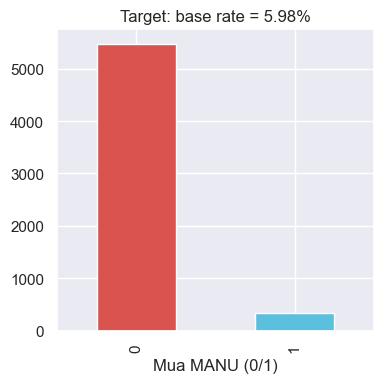

In [15]:
fig, ax = plt.subplots(figsize=(4, 4))
df_train[TARGET].value_counts().plot(kind="bar", color=["#d9534f", "#5bc0de"], ax=ax)
ax.set_title(f"Target: base rate = {base:.2%}")
ax.set_xlabel("Mua MANU (0/1)")
fig.tight_layout(); fig.savefig(f"{OUT_DIR}/00_target.png", dpi=90); plt.show()


In [16]:
from IPython.display import display, Markdown

def plot_feature(df, col, ax_dist, ax_lift):
    if (df[col] == 0).mean() > 0.8:                 # cot thua -> nhi phan
        s = (df[col] > 0).astype(int); xname = f"{col}>0"
    else:
        s = df[col]; xname = col
    tmp = pd.DataFrame({xname: s, TARGET: df[TARGET]})

    # PANEL TRAI: phan phoi theo lop, chuan hoa TRONG TUNG LOP (common_norm=False)
    sns.histplot(data=tmp, x=xname, hue=TARGET, stat="probability",
                 common_norm=False, multiple="dodge", discrete=True,
                 shrink=0.8, ax=ax_dist, legend=(ax_dist.get_subplotspec().rowspan.start == 0))
    ax_dist.set_title(cname(col))                  # ten that tu PDF

    # PANEL PHAI: lift = P(mua | gia tri) / base

def plot_group(df, name, cols):
    n = len(cols)
    fig, axes = plt.subplots(n, 2, figsize=(11, 3 * n))
    axes = np.atleast_2d(axes)
    for i, c in enumerate(cols):
        plot_feature(df, c, axes[i, 0], axes[i, 1])
    fig.suptitle(name, fontsize=14, y=1.0)
    fig.tight_layout()
    fig.savefig(f"{OUT_DIR}/{name}.png", dpi=85, bbox_inches="tight")
    plt.show()                                     # hien anh INLINE trong cell

def plot_product_summary(df, name, cols):
    lifts = {}
    for c in cols:
        mask = df[c] > 0
        lifts[c] = (df.loc[mask, TARGET].mean() / base) if mask.any() else 0.0
    s = pd.Series(lifts).sort_values(ascending=False)
    s.index = [COL_NAME.get(c, c) for c in s.index]   # nhan truc x = ten that
    fig, ax = plt.subplots(figsize=(11, 5))
    s.plot(kind="bar", color="steelblue", ax=ax)
    ax.axhline(1.0, color="red", ls="--", lw=1)
    ax.set_title(f"{name}: lift khi SO HUU (>0) tung loai policy")
    ax.set_ylabel("lift"); ax.set_xlabel("")
    fig.tight_layout()
    fig.savefig(f"{OUT_DIR}/{name}.png", dpi=85, bbox_inches="tight")
    plt.show()                                     # hien anh INLINE trong cell

def iv_label(v):
    return ("vo dung" if v < 0.02 else "yeu" if v < 0.1 else
            "trung binh" if v < 0.3 else "manh" if v < 0.5 else "nghi leakage")


#### 01 · Phân loại khách hàng — IV tổng = 0.581 (mạnh)

- Subtype (cột 1, IV=0.318) & Main type (cột 5, IV=0.263): một số phân khúc có lift cao gấp 2–3 lần trung bình.
- Đòn bẩy **phân khúc khách hàng** — nhắm đúng nhóm có xu hướng mua.

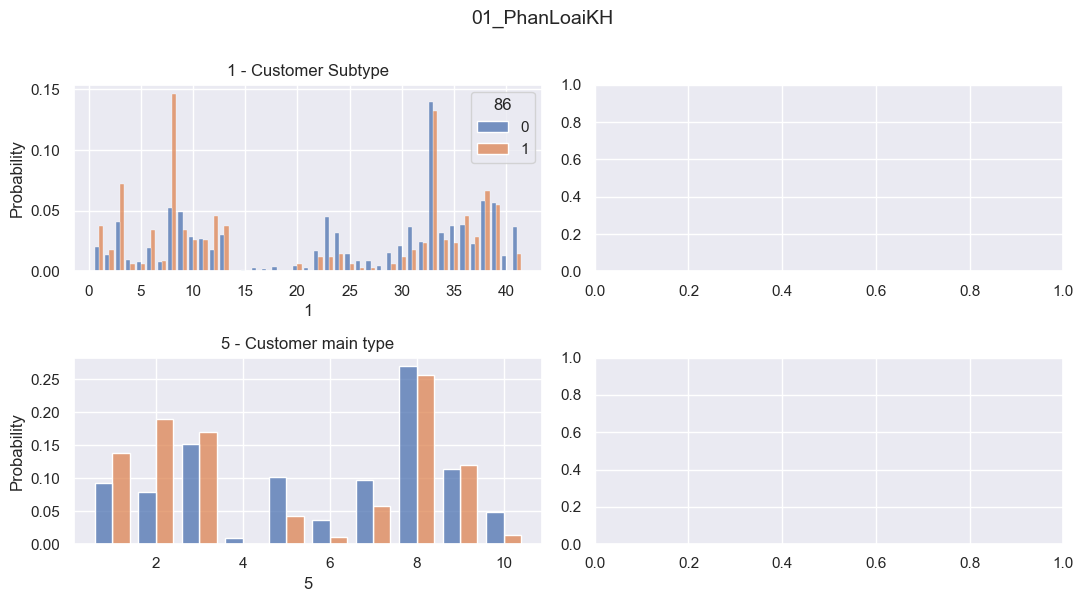

In [17]:
display(Markdown(
    "#### 01 · Phân loại khách hàng — IV tổng = 0.581 (mạnh)\n\n"
    "- Subtype (cột 1, IV=0.318) & Main type (cột 5, IV=0.263): một số phân khúc có lift cao gấp 2–3 lần trung bình.\n"
    "- Đòn bẩy **phân khúc khách hàng** — nhắm đúng nhóm có xu hướng mua."
))
plot_group(df_train, "01_PhanLoaiKH", GROUPS["01_PhanLoaiKH"])

#### 02 · Tôn giáo — IV tổng = 0.188 (yếu)

- Tôn giáo (cột 6–9) ít liên quan tới việc mua MANU.
- Đóng góp dự báo thấp → ưu tiên thấp.

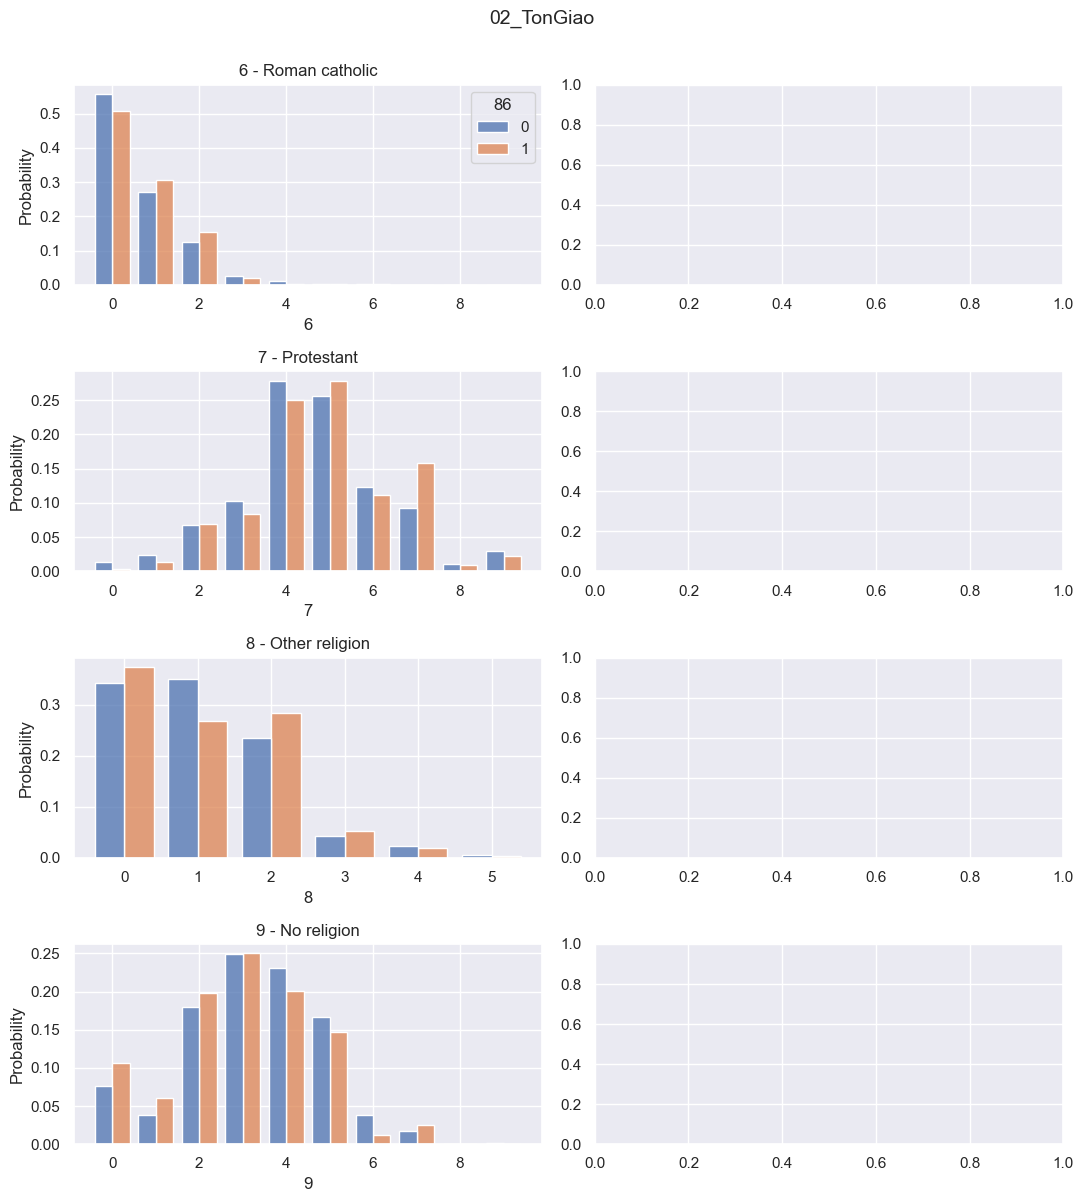

In [18]:
display(Markdown(
    "#### 02 · Tôn giáo — IV tổng = 0.188 (yếu)\n\n"
    "- Tôn giáo (cột 6–9) ít liên quan tới việc mua MANU.\n"
    "- Đóng góp dự báo thấp → ưu tiên thấp."
))
plot_group(df_train, "02_TonGiao", GROUPS["02_TonGiao"])

#### 03 · Quy mô hộ / số nhà — IV tổng = 0.051 (yếu nhất)

- Số nhà (cột 2) & quy mô hộ (cột 3) gần như không phân biệt người mua.
- Ưu tiên thấp khi xây model.

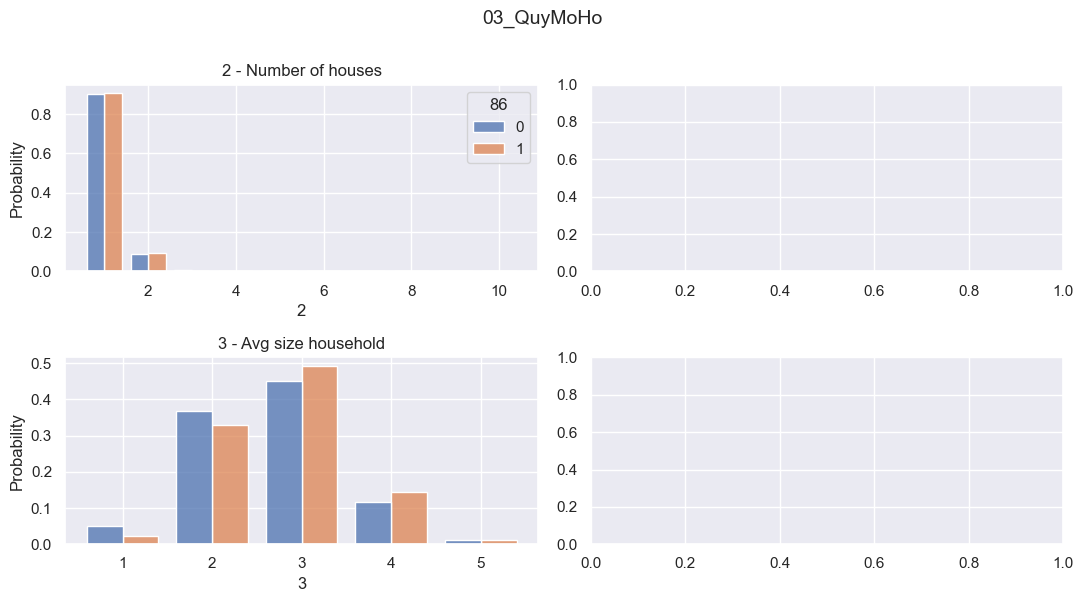

In [19]:
display(Markdown(
    "#### 03 · Quy mô hộ / số nhà — IV tổng = 0.051 (yếu nhất)\n\n"
    "- Số nhà (cột 2) & quy mô hộ (cột 3) gần như không phân biệt người mua.\n"
    "- Ưu tiên thấp khi xây model."
))
plot_group(df_train, "03_QuyMoHo", GROUPS["03_QuyMoHo"])

#### 04 · Gia đình / nhân khẩu — IV tổng = 0.343 (trung bình)

- Tuổi (cột 4), hôn nhân (10–13), con cái (14–15).
- Một số mức tuổi / cấu trúc hộ có lift lệch khỏi 1 → đáng xem.

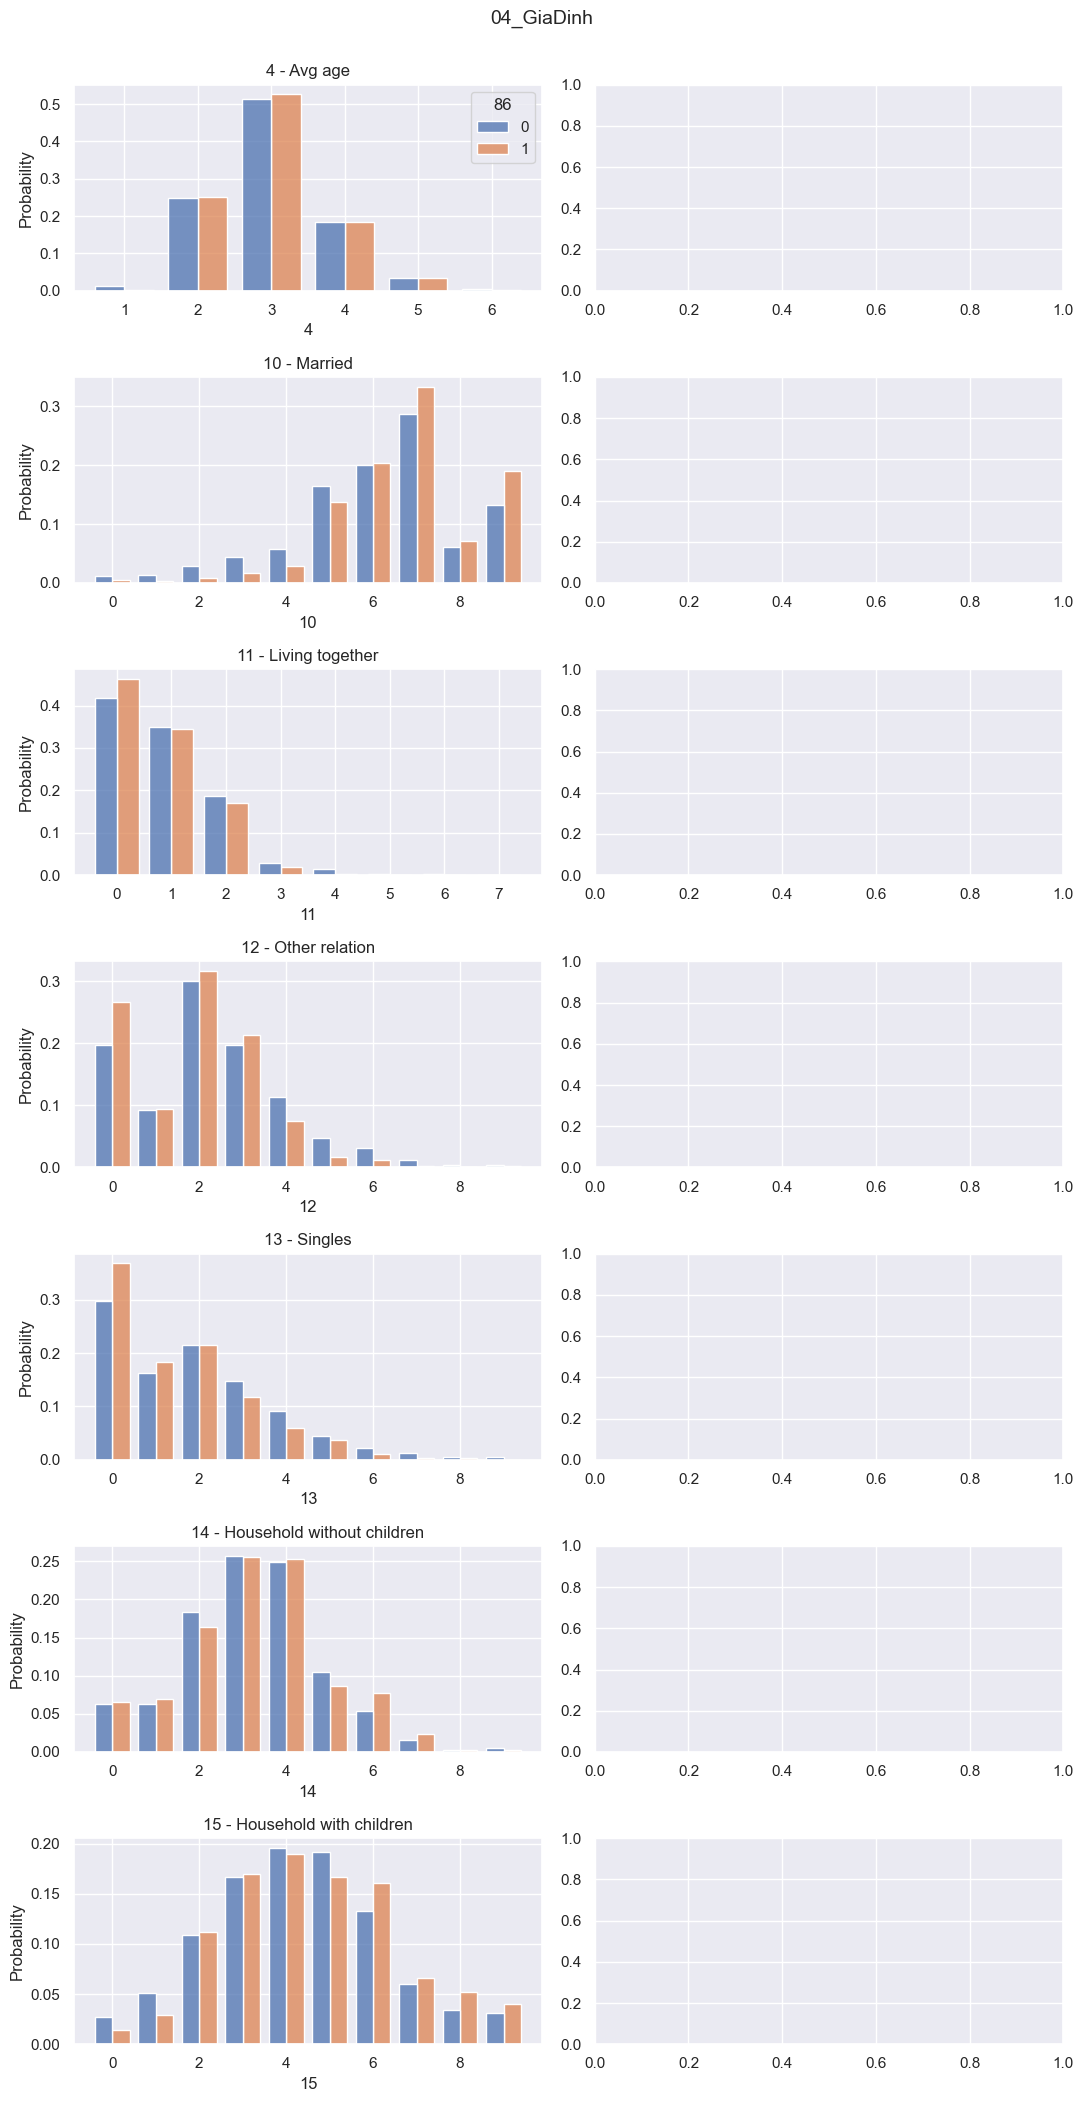

In [20]:
display(Markdown(
    "#### 04 · Gia đình / nhân khẩu — IV tổng = 0.343 (trung bình)\n\n"
    "- Tuổi (cột 4), hôn nhân (10–13), con cái (14–15).\n"
    "- Một số mức tuổi / cấu trúc hộ có lift lệch khỏi 1 → đáng xem."
))
plot_group(df_train, "04_GiaDinh", GROUPS["04_GiaDinh"])

#### 05 · Học vấn — IV tổng = 0.351 (trung bình)

- Lower education (cột 18, IV=0.165) mạnh nhất nhóm.
- Khu vực học vấn cao/thấp khác biệt rõ về tỷ lệ mua.

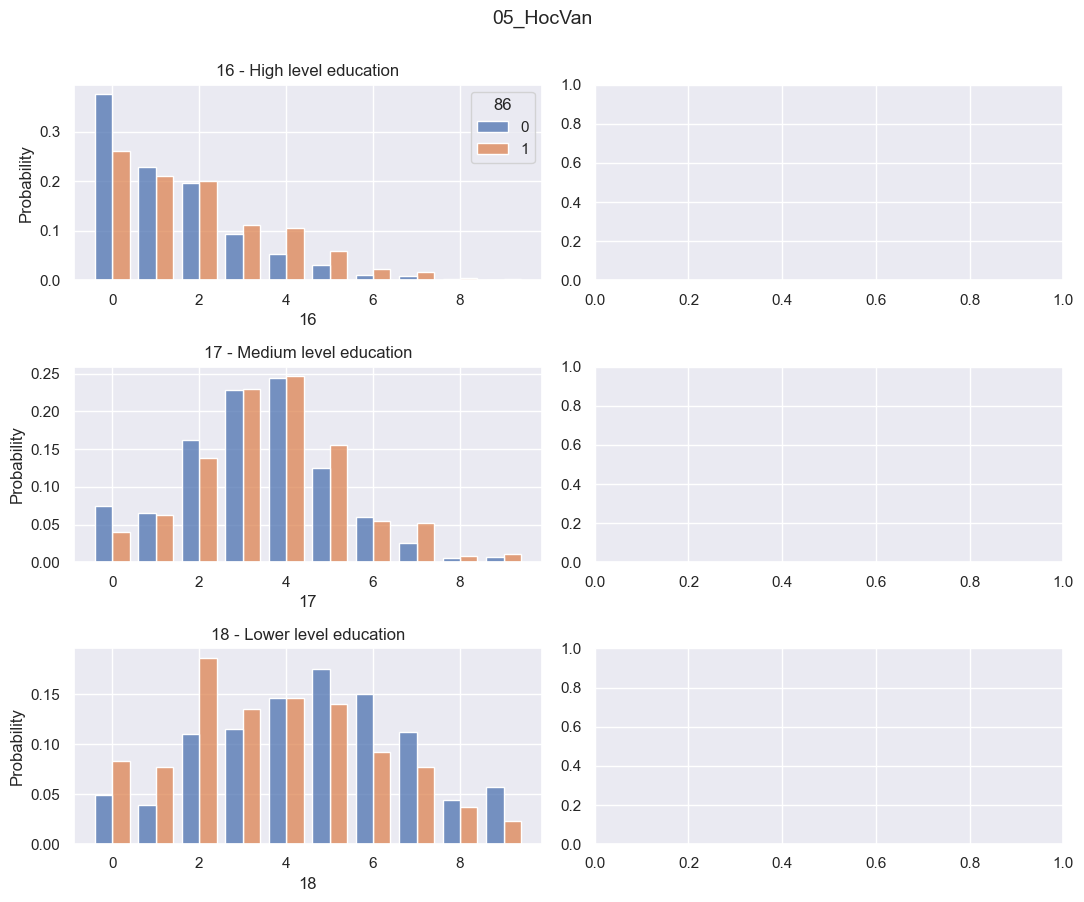

In [21]:
display(Markdown(
    "#### 05 · Học vấn — IV tổng = 0.351 (trung bình)\n\n"
    "- Lower education (cột 18, IV=0.165) mạnh nhất nhóm.\n"
    "- Khu vực học vấn cao/thấp khác biệt rõ về tỷ lệ mua."
))
plot_group(df_train, "05_HocVan", GROUPS["05_HocVan"])

#### 06 · Nghề nghiệp / địa vị — IV tổng = 0.401 (khá)

- 6 cột 19–24 (high status … unskilled).
- Liên quan chặt tới thu nhập & sức mua → nên xem cùng nhóm 11.

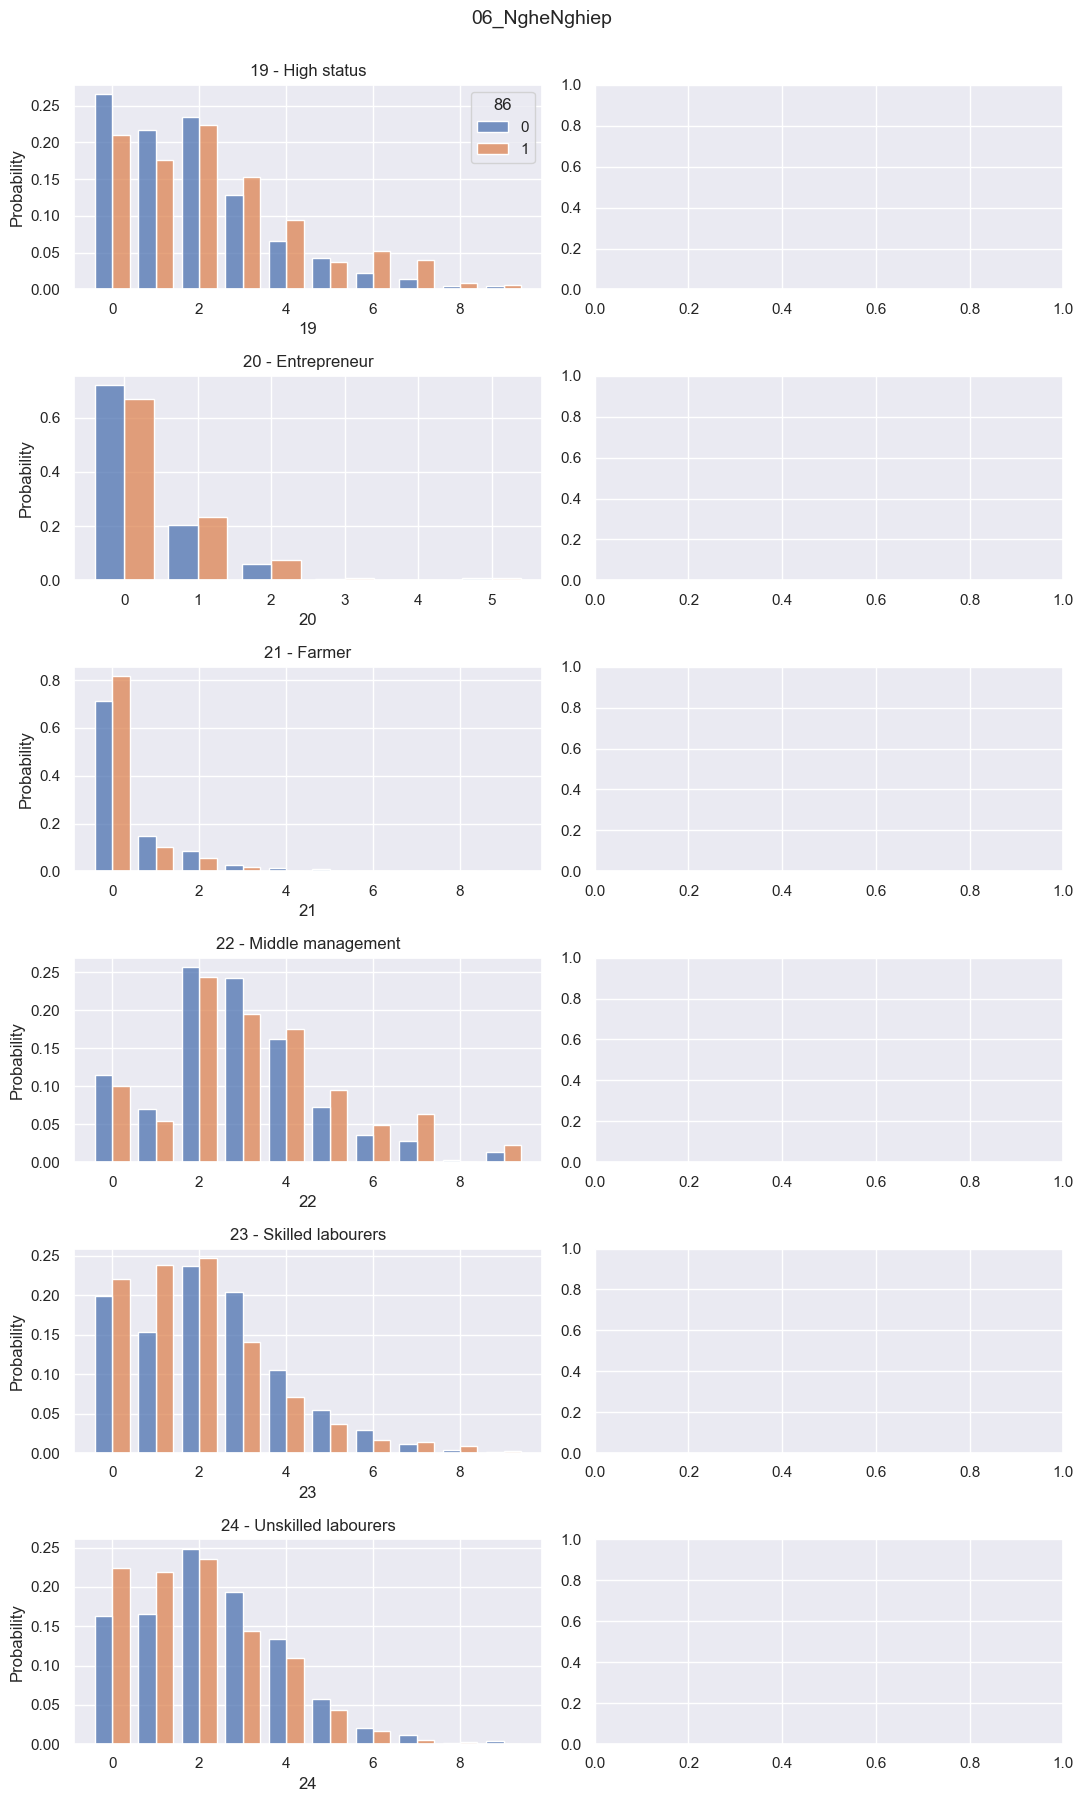

In [22]:
display(Markdown(
    "#### 06 · Nghề nghiệp / địa vị — IV tổng = 0.401 (khá)\n\n"
    "- 6 cột 19–24 (high status … unskilled).\n"
    "- Liên quan chặt tới thu nhập & sức mua → nên xem cùng nhóm 11."
))
plot_group(df_train, "06_NgheNghiep", GROUPS["06_NgheNghiep"])

#### 07 · Tầng lớp xã hội — IV tổng = 0.387 (khá)

- Social class A (cột 25, IV=0.134) nổi bật.
- Khu vực tầng lớp cao → tỷ lệ mua cao hơn.

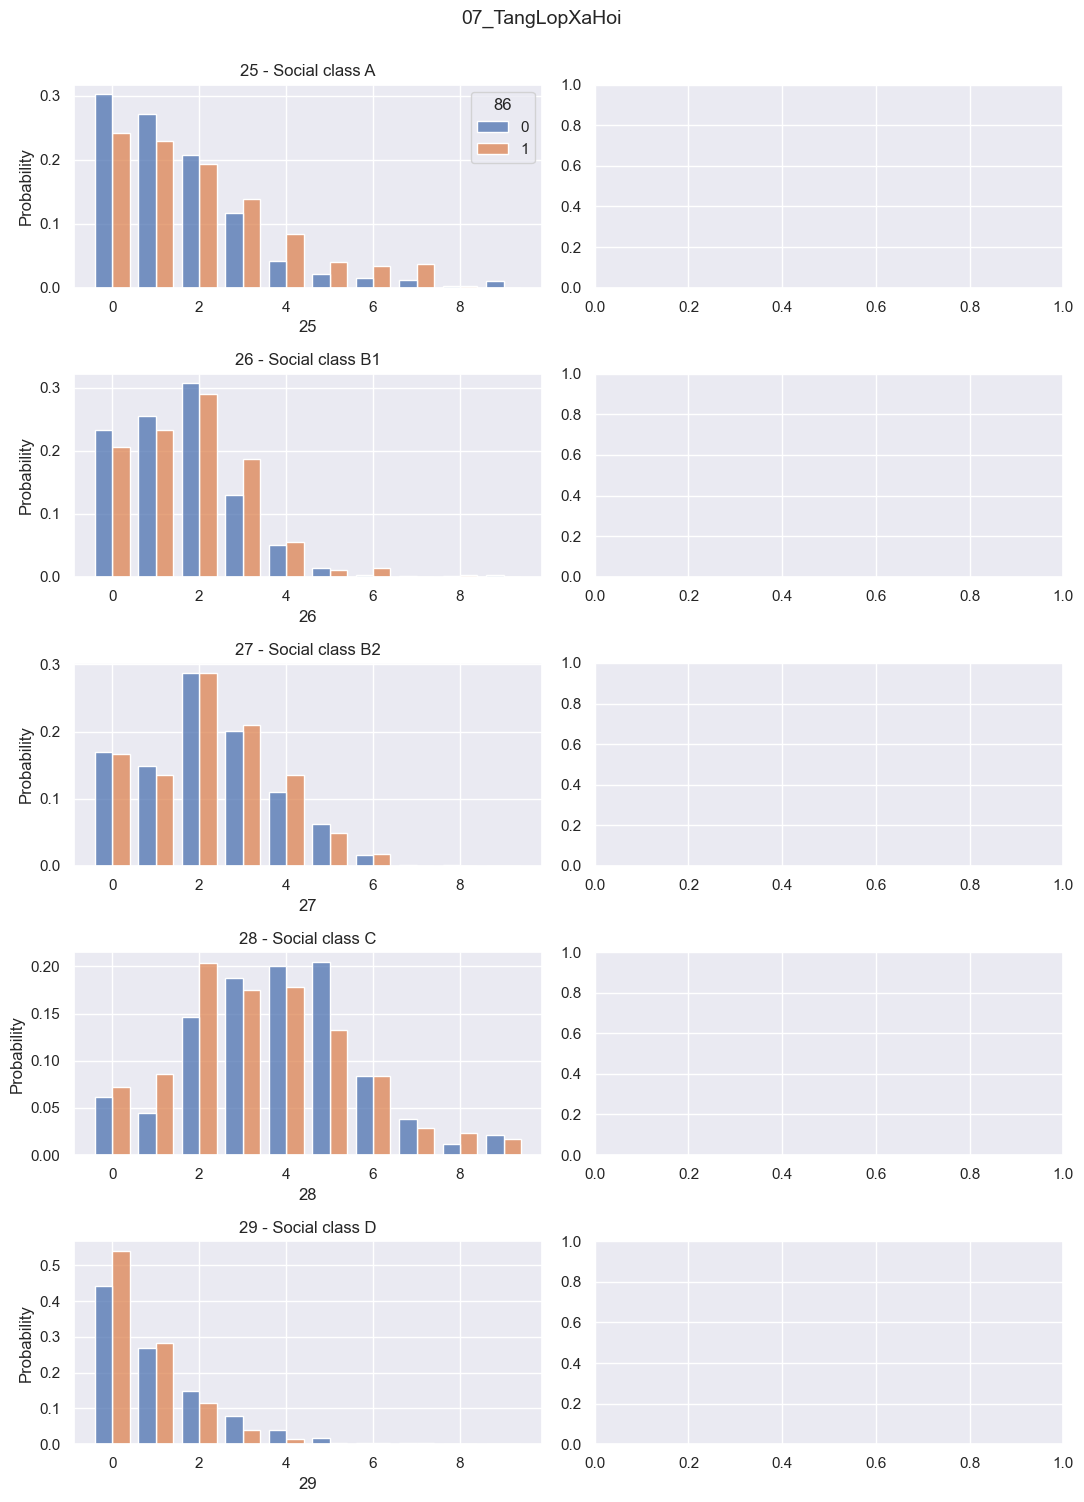

In [23]:
display(Markdown(
    "#### 07 · Tầng lớp xã hội — IV tổng = 0.387 (khá)\n\n"
    "- Social class A (cột 25, IV=0.134) nổi bật.\n"
    "- Khu vực tầng lớp cao → tỷ lệ mua cao hơn."
))
plot_group(df_train, "07_TangLopXaHoi", GROUPS["07_TangLopXaHoi"])

#### 08 · Sở hữu nhà — IV tổng = 0.279 (trung bình)

- Rented (cột 30, IV=0.140) & Home owner (cột 31, IV=0.138) ngược chiều nhau.
- Khu sở hữu nhà cao ↔ ổn định tài chính → tỷ lệ mua khác biệt.

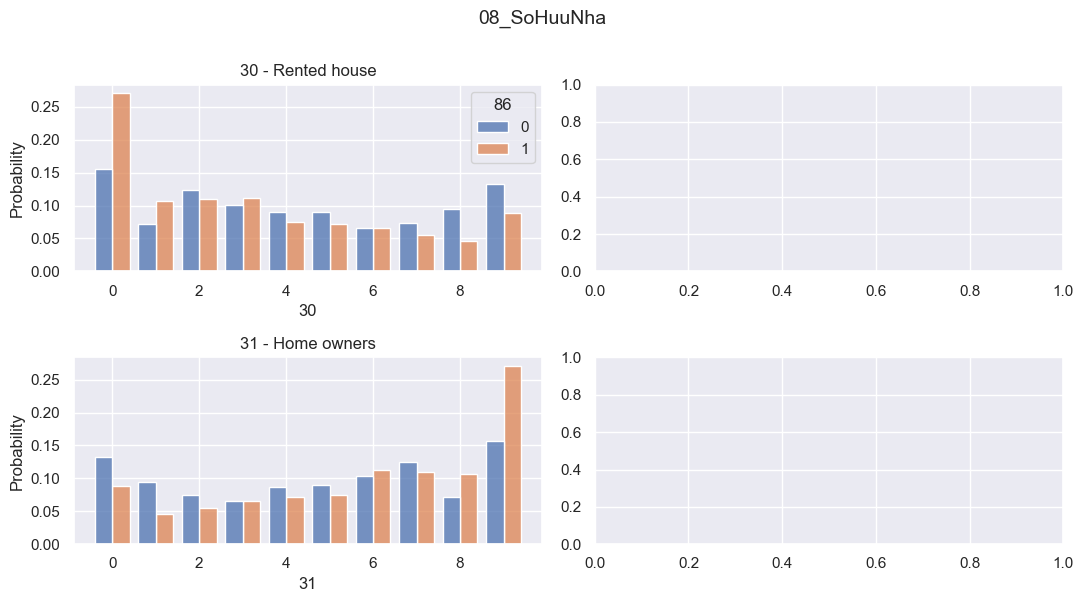

In [24]:
display(Markdown(
    "#### 08 · Sở hữu nhà — IV tổng = 0.279 (trung bình)\n\n"
    "- Rented (cột 30, IV=0.140) & Home owner (cột 31, IV=0.138) ngược chiều nhau.\n"
    "- Khu sở hữu nhà cao ↔ ổn định tài chính → tỷ lệ mua khác biệt."
))
plot_group(df_train, "08_SoHuuNha", GROUPS["08_SoHuuNha"])

#### 09 · Xe ô tô — IV tổng = 0.259 (trung bình)

- 1 car (cột 32) lift tăng dần; No car (cột 34, IV=0.141) giảm dần.
- 2 cars (cột 33, IV=0.008) gần như **vô dụng** — minh chứng nên để EDA quyết định, không bỏ theo cảm tính.

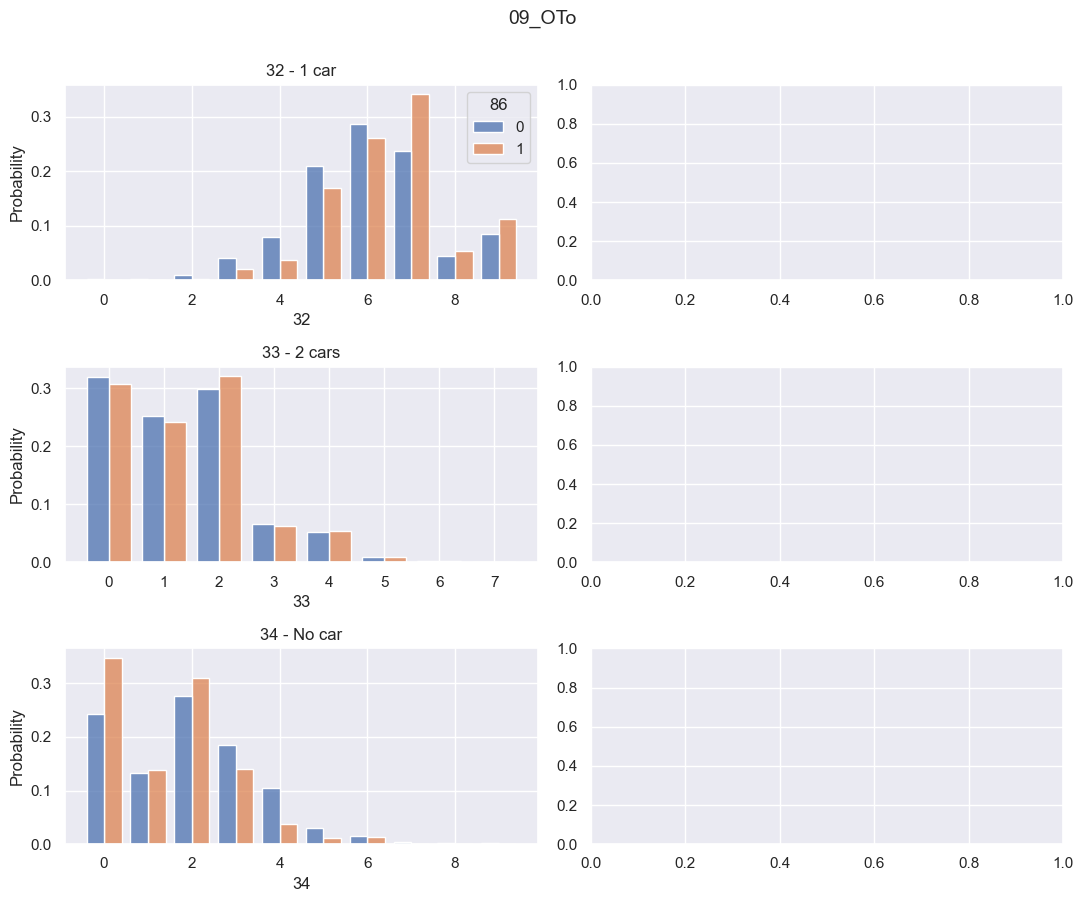

In [25]:
display(Markdown(
    "#### 09 · Xe ô tô — IV tổng = 0.259 (trung bình)\n\n"
    "- 1 car (cột 32) lift tăng dần; No car (cột 34, IV=0.141) giảm dần.\n"
    "- 2 cars (cột 33, IV=0.008) gần như **vô dụng** — minh chứng nên để EDA quyết định, không bỏ theo cảm tính."
))
plot_group(df_train, "09_OTo", GROUPS["09_OTo"])

#### 10 · Bảo hiểm y tế — IV tổng = 0.148 (yếu)

- National Health Service (cột 35) vs Private (cột 36).
- Đóng góp dự báo thấp.

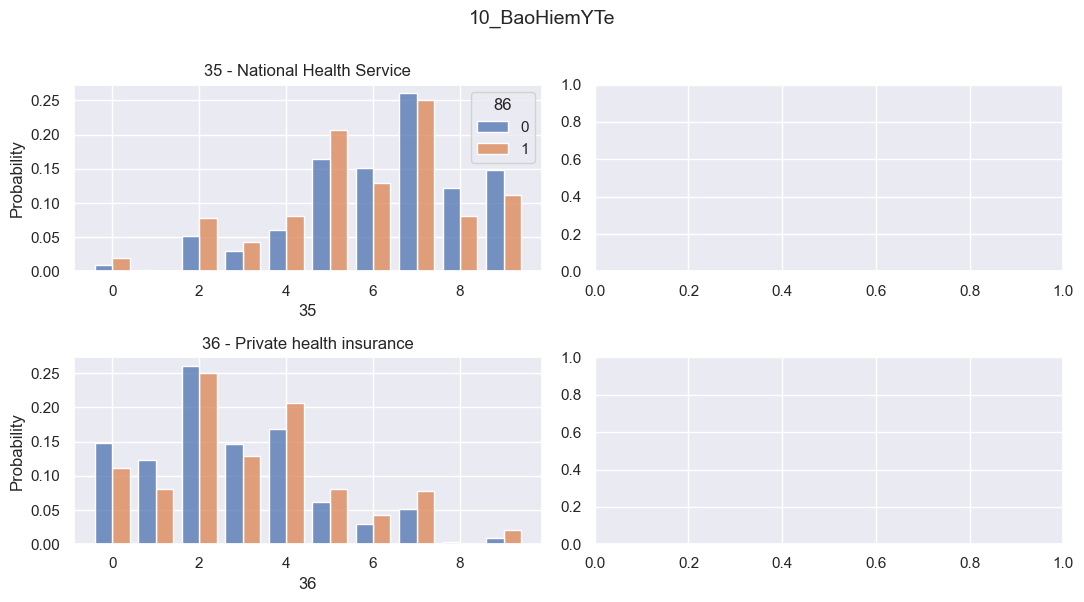

In [26]:
display(Markdown(
    "#### 10 · Bảo hiểm y tế — IV tổng = 0.148 (yếu)\n\n"
    "- National Health Service (cột 35) vs Private (cột 36).\n"
    "- Đóng góp dự báo thấp."
))
plot_group(df_train, "10_BaoHiemYTe", GROUPS["10_BaoHiemYTe"])

#### 11 · Thu nhập & sức mua — IV tổng = 0.830 (mạnh)

- Average income (cột 42, IV=0.221) & Purchasing power (cột 43, IV=0.203).
- ⚠️ Cột 42, 43 là chỉ số ordinal, **KHÔNG phải %** — đọc theo hướng 'càng cao càng giàu'.
- Đòn bẩy **ĐỊA LÝ**: nhắm khu vực có sức mua cao.

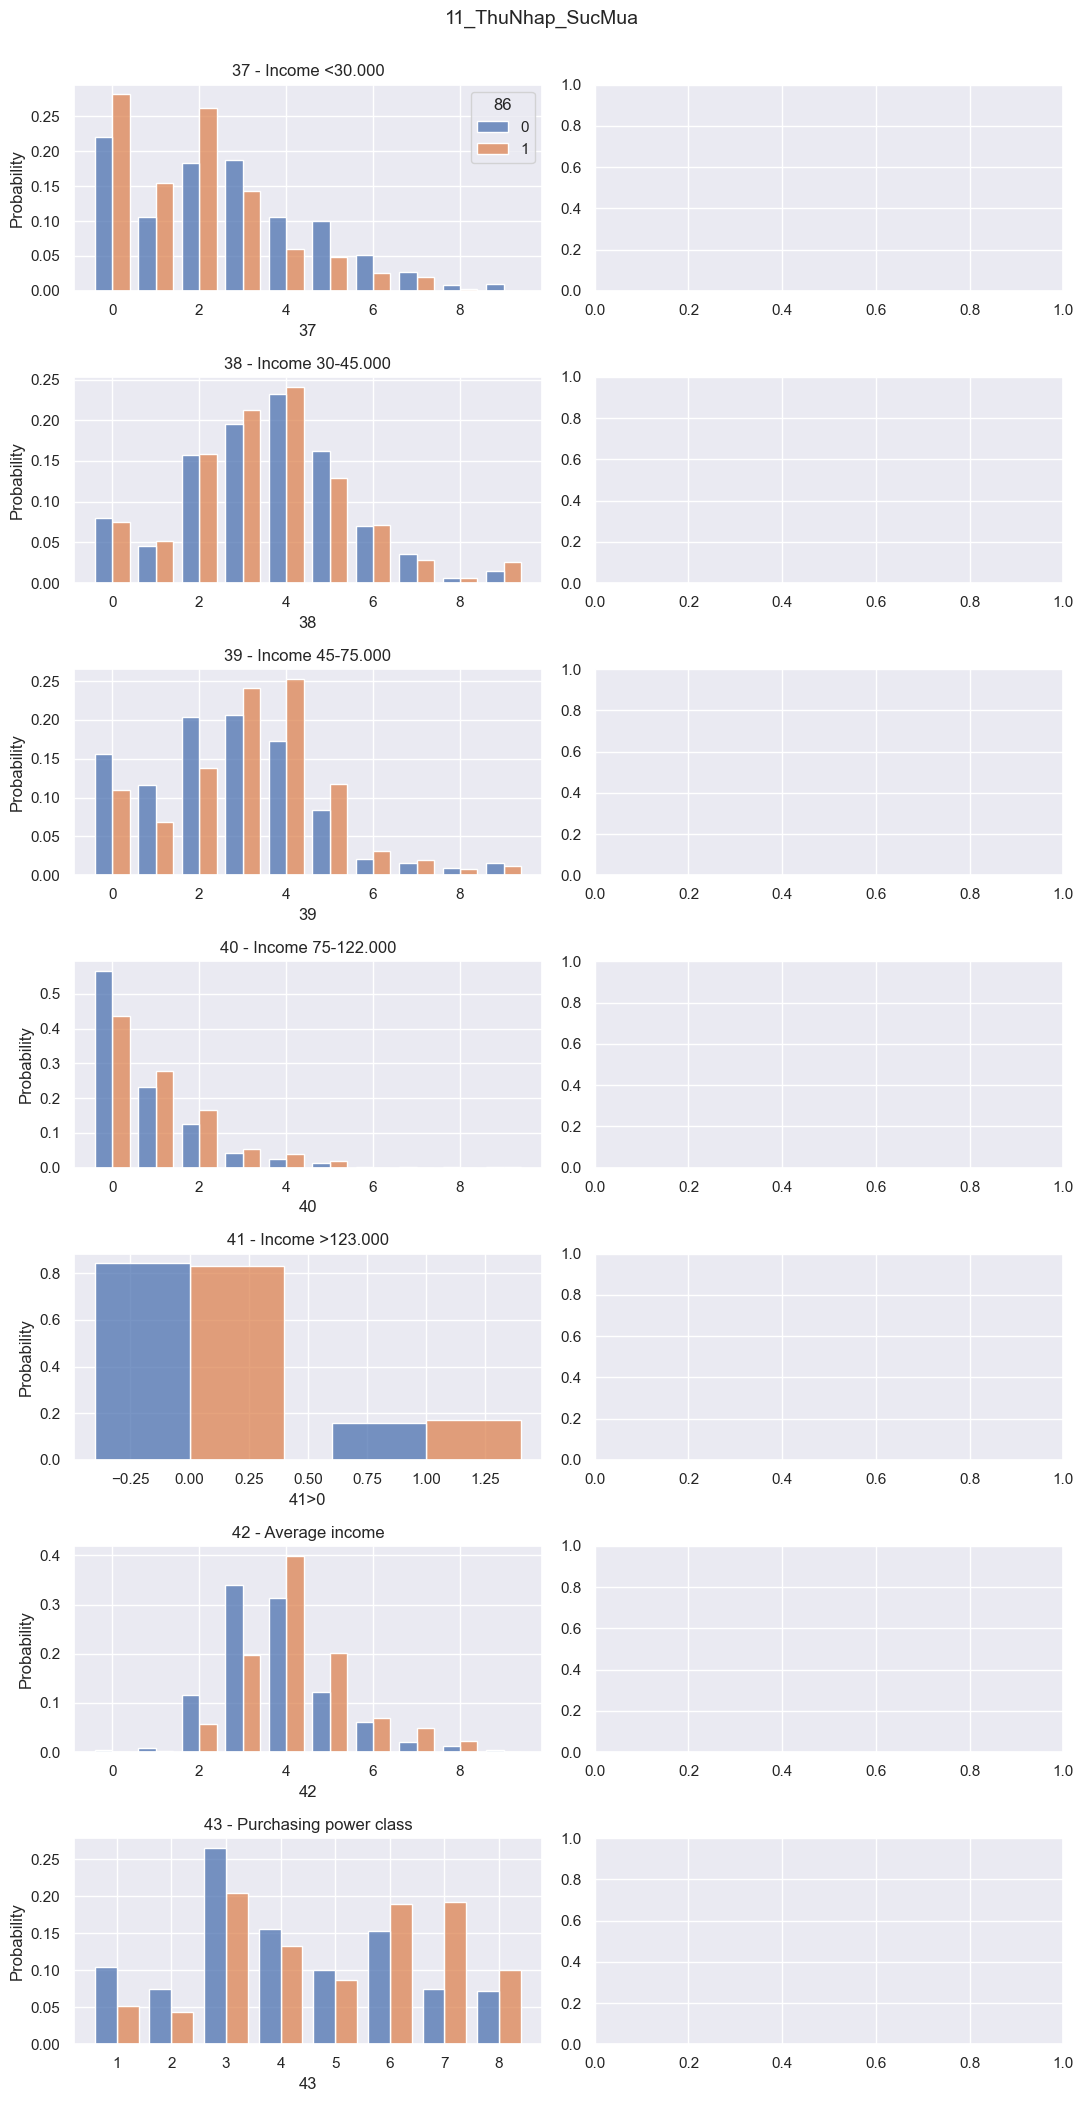

In [27]:
display(Markdown(
    "#### 11 · Thu nhập & sức mua — IV tổng = 0.830 (mạnh)\n\n"
    "- Average income (cột 42, IV=0.221) & Purchasing power (cột 43, IV=0.203).\n"
    "- ⚠️ Cột 42, 43 là chỉ số ordinal, **KHÔNG phải %** — đọc theo hướng 'càng cao càng giàu'.\n"
    "- Đòn bẩy **ĐỊA LÝ**: nhắm khu vực có sức mua cao."
))
plot_group(df_train, "11_ThuNhap_SucMua", GROUPS["11_ThuNhap_SucMua"])

#### 12 · Contribution (đóng phí bảo hiểm) — IV tổng = 1.627 (MẠNH NHẤT)

- Đòn bẩy **CÁ NHÂN**: khách đã đóng phí bảo hiểm liên quan.
- Car (cột 47, IV=0.604) & Fire (cột 59, IV=0.426) mạnh nhất toàn dataset.
- Cột thưa → biểu đồ tóm tắt lift khi 'có sở hữu (>0)'.

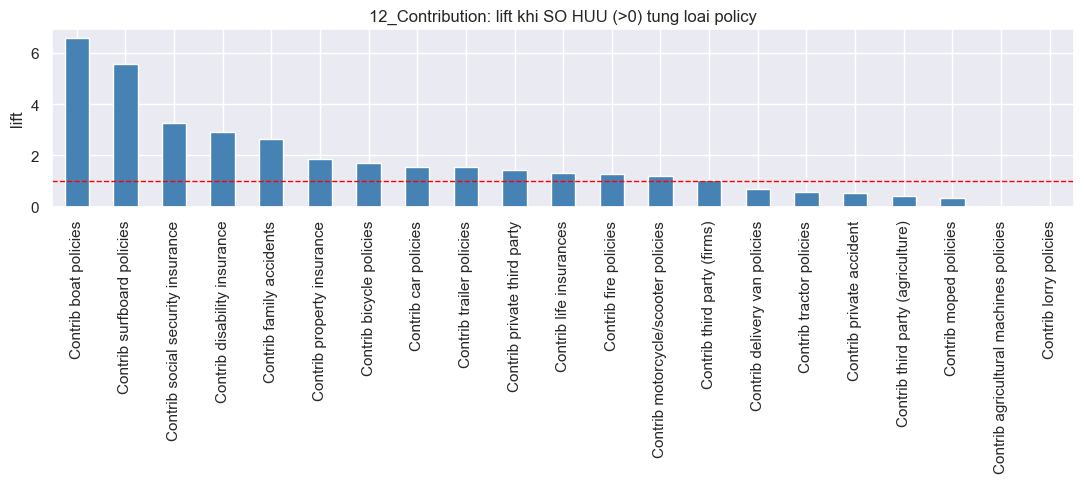

In [28]:
display(Markdown(
    "#### 12 · Contribution (đóng phí bảo hiểm) — IV tổng = 1.627 (MẠNH NHẤT)\n\n"
    "- Đòn bẩy **CÁ NHÂN**: khách đã đóng phí bảo hiểm liên quan.\n"
    "- Car (cột 47, IV=0.604) & Fire (cột 59, IV=0.426) mạnh nhất toàn dataset.\n"
    "- Cột thưa → biểu đồ tóm tắt lift khi 'có sở hữu (>0)'."
))
plot_product_summary(df_train, "12_Contribution", GROUPS["12_Contribution"])

#### 13 · Number (số lượng policy) — IV tổng = 1.024 (mạnh)

- Song hành với nhóm 12 (mỗi cặp corr ~0.9 → **dư thừa**).
- Number car (cột 68, IV=0.440) mạnh nhất nhóm.
- Phase 4: chỉ **giữ MỘT** trong hai bộ (12 hoặc 13).

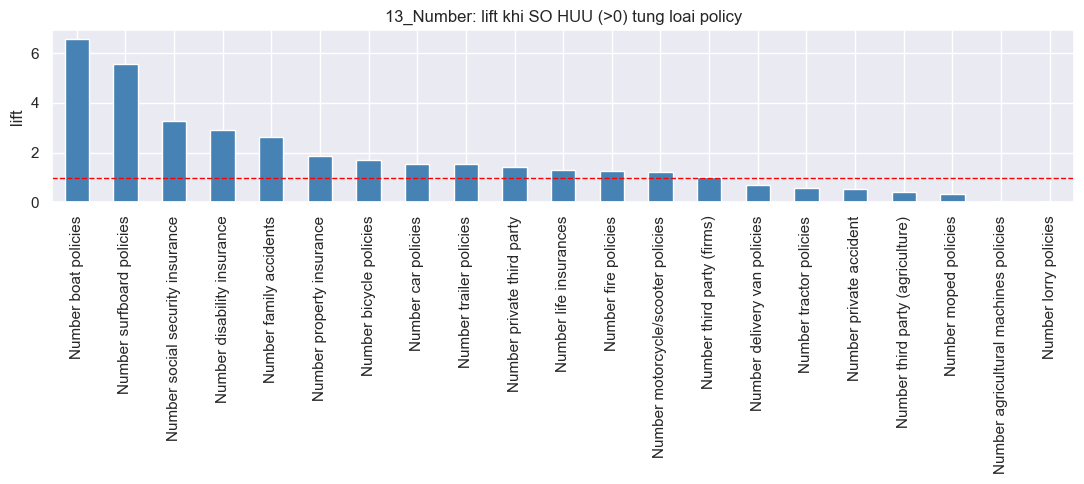

In [29]:
display(Markdown(
    "#### 13 · Number (số lượng policy) — IV tổng = 1.024 (mạnh)\n\n"
    "- Song hành với nhóm 12 (mỗi cặp corr ~0.9 → **dư thừa**).\n"
    "- Number car (cột 68, IV=0.440) mạnh nhất nhóm.\n"
    "- Phase 4: chỉ **giữ MỘT** trong hai bộ (12 hoặc 13)."
))
plot_product_summary(df_train, "13_Number", GROUPS["13_Number"])

In [30]:
print("\n=== TOP 15 FEATURE theo IV ===")
for c, v in iv_feat.head(15).items():
    print(f"  {cname(c):42s} IV={v:.3f}  ({iv_label(v)})")

print("\n=== IV theo NHOM (tong) ===")
grp_iv = {name: sum(iv(df_train, c) for c in cols) for name, cols in GROUPS.items()}
for name, v in sorted(grp_iv.items(), key=lambda x: -x[1]):
    print(f"  {name:20s}: IV_tong={v:.3f}")



=== TOP 15 FEATURE theo IV ===
  47 - Contrib car policies                  IV=0.604  (nghi leakage)
  68 - Number car policies                   IV=0.440  (manh)
  59 - Contrib fire policies                 IV=0.426  (manh)
  1 - Customer Subtype                       IV=0.318  (manh)
  5 - Customer main type                     IV=0.263  (trung binh)
  42 - Average income                        IV=0.221  (trung binh)
  43 - Purchasing power class                IV=0.203  (trung binh)
  37 - Income <30.000                        IV=0.168  (trung binh)
  18 - Lower level education                 IV=0.165  (trung binh)
  44 - Contrib private third party           IV=0.165  (trung binh)
  65 - Number private third party            IV=0.142  (trung binh)
  34 - No car                                IV=0.141  (trung binh)
  30 - Rented house                          IV=0.140  (trung binh)
  31 - Home owners                           IV=0.138  (trung binh)
  25 - Social class A           

In [31]:
print("\n=== CAP DU THUA contribution<->number (corr cao -> giu 1) ===")
red = []
for k in range(21):
    cc, nc = str(44 + k), str(65 + k)            # cung 1 loai policy
    r = df_train[cc].corr(df_train[nc])
    red.append((cc, nc, r))
red_df = pd.DataFrame(red, columns=["contribution", "number", "corr"]).sort_values("corr", ascending=False)
print(red_df.head(10).to_string(index=False))
print(f"  -> {(red_df['corr'] > 0.8).sum()}/21 cap co corr > 0.8")



=== CAP DU THUA contribution<->number (corr cao -> giu 1) ===
contribution number     corr
          46     67 0.987579
          44     65 0.981369
          57     78 0.979969
          54     75 0.969708
          64     85 0.966239
          51     72 0.966081
          50     71 0.948663
          58     79 0.948430
          62     83 0.935854
          52     73 0.929818
  -> 21/21 cap co corr > 0.8


### Ổn định Train vs Test (PSI) — kiểm tra covariate shift

Đề bài nói test gồm 4.000 người *"who were likely to have the policy"* → tập test **đã được lọc trước**, nên phân phối feature có thể **lệch khỏi train**. Đây là rủi ro lớn nhất cho độ tin cậy của Task 1 (ranking 800/4.000) và cũng chính là phần *"kỹ thuật giám sát model"* mà đề yêu cầu giải thích.

Ta đo **PSI (Population Stability Index)** cho từng feature giữa train và test:

| PSI | Ý nghĩa | Hành động |
|---|---|---|
| < 0.10 | ổn định | dùng bình thường |
| 0.10 – 0.25 | lệch nhẹ | theo dõi, cân nhắc khi diễn giải |
| > 0.25 | lệch mạnh | cẩn trọng — feature có thể không ổn định trên test |

→ Nếu nhiều feature lệch mạnh thì validation nội bộ (CV trên train) sẽ **lạc quan hơn** kết quả thật trên test; cần ưu tiên feature ổn định và đánh giá bằng **ranking/lift** thay vì chỉ tin AUC trên CV.

PSI train vs test  | lech nhe (>=0.10): 0 cot | lech manh (>=0.25): 0 cot

=== TOP 12 cot lech phan phoi nhat ===
                    feature    PSI     muc
17 - Medium level education 0.0120 on dinh
                34 - No car 0.0075 on dinh
                21 - Farmer 0.0068 on dinh
      38 - Income 30-45.000 0.0063 on dinh
           31 - Home owners 0.0058 on dinh
     5 - Customer main type 0.0058 on dinh
          30 - Rented house 0.0057 on dinh
        25 - Social class A 0.0056 on dinh
       26 - Social class B1 0.0049 on dinh
 59 - Contrib fire policies 0.0047 on dinh
       1 - Customer Subtype 0.0047 on dinh
43 - Purchasing power class 0.0046 on dinh


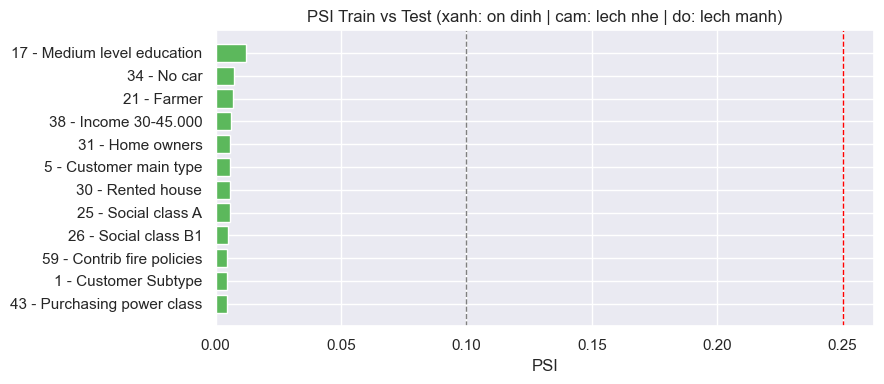

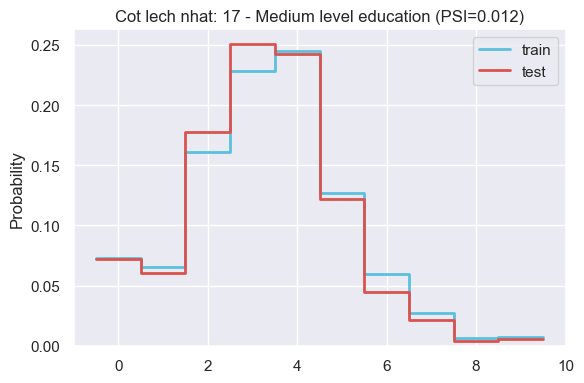

In [32]:
def psi(expected, actual, bins=10, eps=1e-4):
    """Population Stability Index giua TRAIN (expected) va TEST (actual).
    - Cot it gia tri (<=bins unique) -> dung chinh cac gia tri lam bin (hop bien ma hoa 0-9).
    - Cot nhieu gia tri -> chia bin theo phan vi cua TRAIN.
    PSI < 0.10: on dinh | 0.10-0.25: lech nhe | > 0.25: lech manh.
    """
    expected, actual = pd.Series(expected), pd.Series(actual)
    if expected.nunique() <= bins:
        cats = sorted(set(expected.unique()) | set(actual.unique()))
        e = expected.value_counts(normalize=True).reindex(cats).fillna(0.0)
        a = actual.value_counts(normalize=True).reindex(cats).fillna(0.0)
    else:
        edges = np.unique(np.quantile(expected, np.linspace(0, 1, bins + 1)))
        e = pd.cut(expected, edges, include_lowest=True).value_counts(normalize=True).sort_index()
        a = pd.cut(actual,   edges, include_lowest=True).value_counts(normalize=True).sort_index()
    e, a = e.clip(lower=eps), a.clip(lower=eps)
    return float(((a - e) * np.log(a / e)).sum())

def psi_label(v):
    return "on dinh" if v < 0.10 else "lech nhe" if v < 0.25 else "LECH MANH"

# --- Tinh PSI cho toan bo feature (test la sample 'likely to have the policy' -> co the lech) ---
psi_feat = pd.Series({c: psi(df_train[c], df_test[c]) for c in FEATURES}).sort_values(ascending=False)
psi_tbl = pd.DataFrame({
    "feature": [cname(c) for c in psi_feat.index],
    "PSI":     psi_feat.values.round(4),
    "muc":     [psi_label(v) for v in psi_feat.values],
})
psi_tbl.to_csv(OUT_DIR / "eda_psi_train_test.csv", index=False)

n_minor = int((psi_feat >= 0.10).sum())
n_major = int((psi_feat >= 0.25).sum())
report.update(psi_minor=n_minor, psi_major=n_major, psi_max=float(psi_feat.max()))

print(f"PSI train vs test  | lech nhe (>=0.10): {n_minor} cot | lech manh (>=0.25): {n_major} cot")
print("\n=== TOP 12 cot lech phan phoi nhat ===")
print(psi_tbl.head(12).to_string(index=False))

# --- Hinh 1: bar chart top PSI ---
fig, ax = plt.subplots(figsize=(9, 4))
top = psi_feat.head(12)[::-1]
colors = ["#d9534f" if v >= 0.25 else "#f0ad4e" if v >= 0.10 else "#5cb85c" for v in top.values]
ax.barh([cname(c) for c in top.index], top.values, color=colors)
ax.axvline(0.10, color="gray", ls="--", lw=1); ax.axvline(0.25, color="red", ls="--", lw=1)
ax.set_title("PSI Train vs Test (xanh: on dinh | cam: lech nhe | do: lech manh)")
ax.set_xlabel("PSI")
fig.tight_layout(); fig.savefig(OUT_DIR / "eda_psi.png", dpi=100, bbox_inches="tight"); plt.show()

# --- Hinh 2: doi chieu phan phoi train vs test cua cot lech nhat ---
worst = psi_feat.index[0]
fig, ax = plt.subplots(figsize=(6, 4))
for lbl, d, color in [("train", df_train, "#5bc0de"), ("test", df_test, "#d9534f")]:
    sns.histplot(d[worst], stat="probability", discrete=True, element="step",
                 fill=False, label=lbl, color=color, ax=ax, lw=2)
ax.set_title(f"Cot lech nhat: {cname(worst)} (PSI={psi_feat.iloc[0]:.3f})")
ax.set_xlabel(""); ax.legend()
fig.tight_layout(); fig.savefig(OUT_DIR / "eda_psi_worst.png", dpi=100, bbox_inches="tight"); plt.show()


## Feature engineering


Dựa trên *data understanding* ở trên, Phase 4 làm 4 việc (đều **leakage-safe**: encoder fit trên TRAIN, áp lên TEST):

1. **Feature tổng hợp** từ khối sản phẩm (tín hiệu cá nhân mạnh nhất): tổng số policy, tổng đóng phí, số loại policy, cờ có bảo hiểm ô tô / cháy.
2. **Encode nominal (1, 5)** bằng **WoE** (Weight of Evidence) — thay mã số vô nghĩa bằng log-odds của target, vừa bỏ thứ tự giả vừa monotonic với xu hướng mua. ⚠️ WoE dùng target → **WoE full-train** chỉ dùng cho model cuối + dự đoán TEST; trong CV (Phase 5) phải tính **out-of-fold**.
3. **Cắt dư thừa:** bỏ khối Number (65–85) vì trùng Contribution (corr ~0.9) — đã rút thông tin tổng hợp **trước khi** bỏ.
4. **Giữ nguyên** ordinal & compositional cho model cây (chịu được cộng tuyến; chỉ cần WoE cho nominal, không cần cho ordinal).

In [33]:
NUM_COLS = [str(i) for i in range(65, 86)]   # Number of policies (dem)
CON_COLS = [str(i) for i in range(44, 65)]   # Contribution (dong phi)

def add_aggregate_features(df):
    """Rut tin hieu tong hop tu khoi san pham (cap CA NHAN, manh nhat)."""
    out = df.copy()
    out["agg_n_policies"]  = df[NUM_COLS].sum(axis=1)          # tong so policy so huu
    out["agg_tot_contrib"] = df[CON_COLS].sum(axis=1)          # tong muc dong phi
    out["agg_n_types"]     = (df[NUM_COLS] > 0).sum(axis=1)    # so LOAI policy khac nhau
    out["flag_car_ins"]    = (df["47"] > 0).astype(int)        # co bao hiem oto (predictor manh nhat)
    out["flag_fire_ins"]   = (df["59"] > 0).astype(int)        # co bao hiem chay
    return out

def woe_encode(train, test, col, target, eps=0.5):
    """WoE cho cot NOMINAL: thay ma so vo nghia bang log-odds cua target.
       WoE > 0: nhom THIEN VE MUA;  WoE < 0: thien ve khong mua.  eps = smoothing.
       LUU Y: WoE dung target -> fit tren TRAIN. Trong CV phai tinh OUT-OF-FOLD (Phase 5)."""
    g = train.groupby(col)[target]
    event     = g.sum() + eps                        # so MUA (y=1) + smoothing
    non_event = g.count() - g.sum() + eps            # so KHONG mua + smoothing
    woe = np.log((event / event.sum()) / (non_event / non_event.sum()))
    return train[col].map(woe).fillna(0.0), test[col].map(woe).fillna(0.0)

def frequency_encode(train, test, col):
    """(Phuong an thay the, khong leakage) encode theo tan suat tinh tren TRAIN."""
    freq = train[col].value_counts(normalize=True)
    return train[col].map(freq), test[col].map(freq).fillna(0.0)


In [34]:
# 1) Feature tong hop (tinh TRUOC khi bo khoi Number)
tr = add_aggregate_features(df_train)
te = add_aggregate_features(df_test)

# 2) Encode nominal 1, 5 bang WoE (target-aware).
#    Day la WoE FULL-TRAIN -> dung cho model cuoi + du doan TEST.
#    Trong CV (Phase 5) phai tinh WoE OUT-OF-FOLD de tranh leakage.
for c in ["1", "5"]:
    tr[f"woe_{c}"], te[f"woe_{c}"] = woe_encode(df_train, df_test, c, TARGET)

# 3) Cat du thua: bo khoi Number (65-85) + ma nominal tho (1,5 da thay bang woe_)
drop_cols = NUM_COLS + ["1", "5"]
tr = tr.drop(columns=drop_cols)
te = te.drop(columns=drop_cols)

# 4) Tach X, y
y = df_train[TARGET].values
X_train = tr.drop(columns=["ID", TARGET])
X_test  = te.drop(columns=["ID"])

assert list(X_train.columns) == list(X_test.columns), "Cot train/test khong khop!"
print(f"X_train: {X_train.shape} | X_test: {X_test.shape} | so feature = {X_train.shape[1]}")
print("Feature moi:", [c for c in X_train.columns if c.startswith(('agg_', 'flag_', 'woe_'))])


X_train: (5822, 69) | X_test: (4000, 69) | so feature = 69
Feature moi: ['agg_n_policies', 'agg_tot_contrib', 'agg_n_types', 'flag_car_ins', 'flag_fire_ins', 'woe_1', 'woe_5']


Các thuộc tính mới được thêm vào :

- agg_n_policies		Tổng số policy khách đang sở hữu
- agg_tot_contrib		Tổng mức đóng phí bảo hiểm
- agg_n_types		    Số LOẠI policy khác nhau (độ đa dạng)
- flag_car_ins		    Có bảo hiểm ô tô không (0/1)	
- flag_fire_ins		    Có bảo hiểm cháy không (0/1)
- woe_1 : Cột 1 sau khi áp dụng phương pháp WoE
- woe_5 : Cột 5 sau khi áp dụng WoE

## Modeling

Đây là bài **ranking** (chọn top-800/4000) trên dữ liệu **mất cân bằng** (5.98%) → quy trình modeling bám 4 nguyên tắc:

1. **Metric đúng:** không dùng accuracy. Dùng **AUC** (xếp hạng tổng thể) + **precision@top-20%** & **lift** (mô phỏng việc lọc 800/4000 = 20%).
2. **Validation chống lệch:** **Stratified K-Fold** (giữ đúng tỉ lệ 5.98% ở mỗi fold) → ước lượng ổn định.
3. **Chống leakage:** WoE (cột 1, 5) dùng target nên phải tính **OUT-OF-FOLD** — encode lại trong từng fold qua `make_features(train_fold, valid_fold)`.
4. **Xử lý mất cân bằng trong model:** `class_weight='balanced'` (LogReg/RF) và `scale_pos_weight` (LightGBM).

Thứ tự: baseline (Logistic) → model cây (RF, LightGBM) → so sánh → feature importance → finetune → xuất 800 ID.

In [35]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# ===== 1) Tao feature LEAKAGE-SAFE: WoE fit tren train_df, ap len other_df =====
DROP_COLS = NUM_COLS + ["1", "5"]          # bo khoi Number (du thua) + nominal tho
def make_features(train_df, other_df):
    """Tra ve (X_train, X_other). Dung cho ca CV (fold) lan final (full -> test).
       WoE chi nhin train_df -> khong ro ri target tu valid/test."""
    tr = add_aggregate_features(train_df)
    ot = add_aggregate_features(other_df)
    for c in ["1", "5"]:
        tr[f"woe_{c}"], ot[f"woe_{c}"] = woe_encode(train_df, other_df, c, TARGET)
    drop = [c for c in DROP_COLS if c in tr.columns]
    Xtr = tr.drop(columns=[c for c in ["ID", TARGET] if c in tr.columns] + drop)
    Xot = ot.drop(columns=[c for c in ["ID", TARGET] if c in ot.columns] + drop)
    return Xtr, Xot

# ===== 2) Metric cho bai RANKING =====
SELECT_FRAC = 0.20                          # 800/4000 = 20%
def precision_at_frac(y_true, scores, frac=SELECT_FRAC):
    """Ti le KH that su mua trong nhom top-frac diem cao nhat."""
    k = max(1, int(round(len(scores) * frac)))
    idx = np.argsort(scores)[::-1][:k]
    return y_true[idx].mean()
def lift_at_frac(y_true, scores, frac=SELECT_FRAC):
    return precision_at_frac(y_true, scores, frac) / y_true.mean()

# ===== 3) CV: tra ve du doan OUT-OF-FOLD cho toan bo train =====
def cross_val_oof(make_model, n_splits=5, seed=42):
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=seed)
    y = df_train[TARGET].values
    oof = np.zeros(len(df_train))
    for tr_idx, va_idx in skf.split(df_train, y):
        tr_df, va_df = df_train.iloc[tr_idx], df_train.iloc[va_idx]
        Xtr, Xva = make_features(tr_df, va_df)        # WoE OOF tinh tai day
        model = make_model()
        model.fit(Xtr, tr_df[TARGET].values)
        oof[va_idx] = model.predict_proba(Xva)[:, 1]
    return oof, y

# ===== 4) Luu ket qua de so sanh =====
cv_results, OOF = [], {}
def eval_oof(name, oof, y):
    row = {"model": name, "AUC": roc_auc_score(y, oof),
           "P@20%": precision_at_frac(y, oof), "lift": lift_at_frac(y, oof)}
    cv_results.append(row); OOF[name] = oof
    print(f"{name:18s} AUC={row['AUC']:.4f}  P@20%={row['P@20%']:.4f}  lift={row['lift']:.2f}x")
    return oof

SCALE_POS_WEIGHT = (1 - base) / base
print(f"Base rate={base:.4f} | scale_pos_weight={SCALE_POS_WEIGHT:.2f} | Stratified 5-fold")

Base rate=0.0598 | scale_pos_weight=15.73 | Stratified 5-fold


### Baseline model

In [36]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

# Logistic = mo hinh TUYEN TINH, de giai thich -> lam MOC tham chieu.
# StandardScaler vi LogReg nhay voi thang do; class_weight can bang lop hiem.
def make_logreg():
    return make_pipeline(
        StandardScaler(),
        LogisticRegression(max_iter=2000, class_weight="balanced", C=1.0, random_state=42))

oof_lr, y_all = cross_val_oof(make_logreg)
_ = eval_oof("LogReg (baseline)", oof_lr, y_all)

LogReg (baseline)  AUC=0.7436  P@20%=0.1460  lift=2.44x


### Other model

In [37]:
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb

# Model CAY: chiu duoc da cong tuyen + phi tuyen + tuong tac -> hop du lieu nay.
def make_rf():
    return RandomForestClassifier(
        n_estimators=400, min_samples_leaf=20, max_features="sqrt",
        class_weight="balanced_subsample", n_jobs=-1, random_state=42)

def make_lgbm():
    return lgb.LGBMClassifier(
        n_estimators=600, learning_rate=0.02, num_leaves=31,
        subsample=0.8, colsample_bytree=0.8, min_child_samples=30,
        scale_pos_weight=SCALE_POS_WEIGHT, importance_type="gain",
        random_state=42, n_jobs=-1, verbose=-1)

oof_rf,  _ = cross_val_oof(make_rf);   _ = eval_oof("RandomForest", oof_rf,  y_all)
oof_lgb, _ = cross_val_oof(make_lgbm); _ = eval_oof("LightGBM",     oof_lgb, y_all)

RandomForest       AUC=0.7645  P@20%=0.1512  lift=2.53x
LightGBM           AUC=0.7330  P@20%=0.1418  lift=2.37x


## Đánh giá

                      AUC   P@20%    lift
model                                    
RandomForest       0.7645  0.1512  2.5296
LogReg (baseline)  0.7436  0.1460  2.4434
LightGBM           0.7330  0.1418  2.3715

Model tot nhat (theo AUC): RandomForest


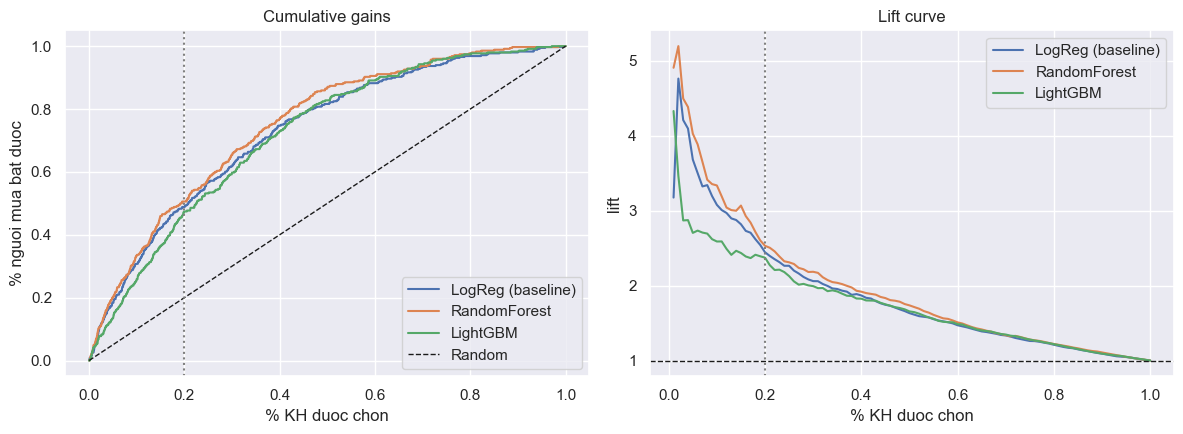

Tai top-20%, % nguoi mua bat duoc: {'LogReg (baseline)': np.float64(0.489), 'RandomForest': np.float64(0.506), 'LightGBM': np.float64(0.474)}


In [38]:
# Bang so sanh CV
cmp = pd.DataFrame(cv_results).set_index("model").sort_values("AUC", ascending=False)
print(cmp.round(4).to_string())
best_name = cmp.index[0]
print("\nModel tot nhat (theo AUC):", best_name)

# Cumulative gains + Lift curve (so sanh cac model bang du doan OOF)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))
fracs = np.linspace(0.01, 1.0, 100)
xs = np.arange(1, len(y_all) + 1) / len(y_all)
for name, oof in OOF.items():
    order = np.argsort(oof)[::-1]
    gains = np.cumsum(y_all[order]) / y_all.sum()
    ax1.plot(xs, gains, label=name)
    ax2.plot(fracs, [lift_at_frac(y_all, oof, f) for f in fracs], label=name)
ax1.plot([0, 1], [0, 1], "k--", lw=1, label="Random")
ax1.axvline(0.2, color="grey", ls=":")
ax1.set(title="Cumulative gains", xlabel="% KH duoc chon", ylabel="% nguoi mua bat duoc"); ax1.legend()
ax2.axhline(1, color="k", ls="--", lw=1); ax2.axvline(0.2, color="grey", ls=":")
ax2.set(title="Lift curve", xlabel="% KH duoc chon", ylabel="lift"); ax2.legend()
plt.tight_layout(); plt.show()

k20 = int(0.2 * len(y_all))
print("Tai top-20%, % nguoi mua bat duoc:",
      {n: round(np.cumsum(y_all[np.argsort(o)[::-1]])[k20] / y_all.sum(), 3) for n, o in OOF.items()})

## Feature importance/Giải thích

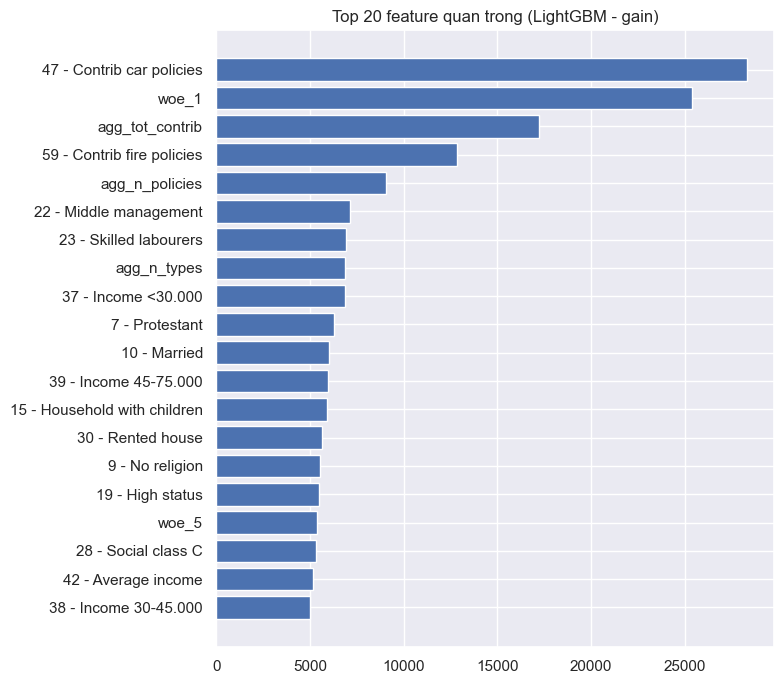

Feature manh nhat -> vat lieu cho Task 2 (chan dung nguoi mua MANU):
  47 - Contrib car policies                gain=28339
  woe_1                                    gain=25374
  agg_tot_contrib                          gain=17195
  59 - Contrib fire policies               gain=12847
  agg_n_policies                           gain=9078
  22 - Middle management                   gain=7125
  23 - Skilled labourers                   gain=6935
  agg_n_types                              gain=6881


In [39]:
# Doc do quan trong tu LightGBM (refit tren FULL train, importance = gain)
X_tr_full, X_te_full = make_features(df_train, df_test)
imp_model = make_lgbm()
imp_model.fit(X_tr_full, df_train[TARGET].values)

imp = pd.Series(imp_model.feature_importances_, index=X_tr_full.columns).sort_values(ascending=False)
imp_named = imp.rename(lambda c: cname(c) if c.isdigit() else c)

top = imp_named.head(20)[::-1]
fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(top.index, top.values, color="#4C72B0")
ax.set_title("Top 20 feature quan trong (LightGBM - gain)")
plt.tight_layout(); plt.show()

print("Feature manh nhat -> vat lieu cho Task 2 (chan dung nguoi mua MANU):")
for c, v in imp.head(8).items():
    print(f"  {(cname(c) if c.isdigit() else c):40s} gain={v:.0f}")

## Finetune

In [40]:
# Tinh chinh LightGBM bang chinh CV LEAKAGE-SAFE o tren (toi uu AUC).
# Grid nho de chay nhanh; co the mo rong neu can.
import itertools
param_grid = {
    "n_estimators":      [400, 800],
    "learning_rate":     [0.02, 0.05],
    "num_leaves":        [15, 31],
    "min_child_samples": [30, 60],
}
keys = list(param_grid)
best = {"auc": -1, "params": None, "oof": None}
for combo in itertools.product(*param_grid.values()):
    p = dict(zip(keys, combo))
    mk = lambda p=p: lgb.LGBMClassifier(
        subsample=0.8, colsample_bytree=0.8, scale_pos_weight=SCALE_POS_WEIGHT,
        importance_type="gain", random_state=42, n_jobs=-1, verbose=-1, **p)
    oof, _ = cross_val_oof(mk)
    auc = roc_auc_score(y_all, oof)
    if auc > best["auc"]:
        best.update(auc=auc, params=p, oof=oof)

BEST_PARAMS = best["params"]
print("Best params:", BEST_PARAMS)
print(f"Best CV: AUC={best['auc']:.4f}  P@20%={precision_at_frac(y_all, best['oof']):.4f}  "
      f"lift={lift_at_frac(y_all, best['oof']):.2f}x")
_ = eval_oof("LightGBM (tuned)", best["oof"], y_all)

Best params: {'n_estimators': 400, 'learning_rate': 0.02, 'num_leaves': 15, 'min_child_samples': 60}
Best CV: AUC=0.7524  P@20%=0.1469  lift=2.46x
LightGBM (tuned)   AUC=0.7524  P@20%=0.1469  lift=2.46x


## Run test and output

In [41]:
# Refit model cuoi voi BEST_PARAMS tren TOAN BO train -> du doan 4000 KH test.
X_tr_full, X_te_full = make_features(df_train, df_test)
final_model = lgb.LGBMClassifier(
    subsample=0.8, colsample_bytree=0.8, scale_pos_weight=SCALE_POS_WEIGHT,
    importance_type="gain", random_state=42, n_jobs=-1, verbose=-1, **BEST_PARAMS)
final_model.fit(X_tr_full, df_train[TARGET].values)
test_proba = final_model.predict_proba(X_te_full)[:, 1]

N_SELECT = 800
submission = (pd.DataFrame({"ID": df_test["ID"].values, "proba_MANU": test_proba})
                .sort_values("proba_MANU", ascending=False).reset_index(drop=True))
submission["rank"] = submission.index + 1
submission["selected"] = (submission["rank"] <= N_SELECT).astype(int)

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
sub_path = OUTPUT_DIR / "predictions.csv"
top_path = OUTPUT_DIR / "selected_800_ids.txt"
submission.to_csv(sub_path, index=False)
submission.loc[submission.selected == 1, "ID"].to_csv(top_path, index=False, header=False)

print(f"Da chon {int(submission.selected.sum())} KH (top {N_SELECT}/{len(submission)}).")
print("Nguong xac suat tai vi tri 800:", round(submission.loc[N_SELECT-1, 'proba_MANU'], 4))
print("Du kien so nguoi mua trong nhom chon ~",
      round(submission.loc[submission.selected == 1, 'proba_MANU'].sum(), 0))
print("Da luu:", sub_path.name, "+", top_path.name, "trong thu muc", OUTPUT_DIR.name)
display(submission.head(10))

Da chon 800 KH (top 800/4000).
Nguong xac suat tai vi tri 800: 0.5204
Du kien so nguoi mua trong nhom chon ~ 548.0
Da luu: predictions.csv + selected_800_ids.txt trong thu muc output


,ID,proba_MANU,rank,selected
0,948,0.925233,1,1
1,2622,0.912408,2,1
2,1690,0.906532,3,1
3,2136,0.902038,4,1
4,2417,0.901716,5,1
5,2113,0.901716,6,1
6,2588,0.898836,7,1
7,1243,0.897661,8,1
8,166,0.897661,9,1
9,2844,0.897661,10,1
